In [32]:
# ============================================================
# LASSO + ELASTIC NET BY SECTOR
# 6 sectors × 4 outcomes × 2 models = 48 models
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings("ignore")

In [33]:
# ── OUTPUT FOLDER ─────────────────────────────────────────────
OUTPUT_DIR = Path("output/sector_models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [34]:
root = next(p for p in Path.cwd().parents if (p / "config.yml").exists())

df = pd.read_parquet(
    root / "data/processed_data/analysis_panel.parquet",
    engine="fastparquet"
)

df.columns = df.columns.str.strip().str.lower()

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Sectors: {df['is8_sector'].unique()}")

Loaded: 17,150 rows × 57 columns
Sectors: ['Advanced Manufacturing', 'Creative Industries', 'Defence', 'Digital and Technologies', 'Financial Services', 'Life Sciences', 'Professional and Business Services']
Categories (7, object): ['Advanced Manufacturing', 'Creative Industries', 'Defence', 'Digital and Technologies', 'Financial Services', 'Life Sciences', 'Professional and Business Services']


In [35]:
for i, col in enumerate(df.columns.tolist()):
    print(f"{i:>3}. {col}")

  0. year
  1. geography_code
  2. geography_name
  3. is8_sector
  4. employees
  5. businesses
  6. gva_per_hour
  7. weekly_pay
  8. employment_rate
  9. unemployment_rate
 10. gdhi_per_head
 11. new_enterprises
 12. deaths_of_enterprises
 13. active_enterprises
 14. high_growth_enterprises
 15. public_transport_to_employer
 16. drive_to_employer
 17. cycle_to_employer
 18. broadband_availability
 19. 4g_area_coverage
 20. ks2_attainment
 21. gcse_by_age_19
 22. ofsted
 23. persistent_absences
 24. persistent_absences_fsm
 25. persistent_absences_cla
 26. early_years_comms
 27. early_years_literacy
 28. early_years_maths
 29. fe_and_skills_achievements
 30. apprenticeship_starts
 31. apprenticeship_achievements
 32. level_3+_qualifications
 33. fe_and_skills_participation
 34. female_hle
 35. male_hle
 36. smokers
 37. reception_obesity
 38. year_6_obesity
 39. adult_obesity
 40. cancer_diagnosis
 41. under_75_mortality_rate
 42. life_satisfaction
 43. worthwhile
 44. happiness
 45.

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct':   missing_pct
}).sort_values('missing_pct', ascending=False)

print(summary[summary['missing_count'] > 0])

                              missing_count  missing_pct
persistent_absences_cla               10976         64.0
persistent_absences                   10927         63.7
persistent_absences_fsm               10927         63.7
fe_and_skills_achievements            10878         63.4
ofsted                                10780         62.9
ks2_attainment                        10682         62.3
male_hle                               8330         48.6
female_hle                             8330         48.6
cancer_diagnosis                       4263         24.9
drive_to_employer                      3479         20.3
cycle_to_employer                      3479         20.3
public_transport_to_employer           3479         20.3
size_micro_share                       3172         18.5
size_large_share                       3172         18.5
gcse_by_age_19                         2891         16.9
cagr_bus                               2870         16.7
growth_bus                     

In [9]:
# ── CONFIGURATION ─────────────────────────────────────────────

# The 13 predictors selected based on EEG framework
# Excluded: gva_per_hour, weekly_pay, gdhi_per_head, employment_rate
#           (reverse causality — IS8 presence drives these outcomes)
# Excluded: transport variables (missing 17 English LADs)
# Excluded: unemployment_rate (r = -0.07 with outcomes, costs 21 LADs)
# Excluded: health/wellbeing, early years (no EEG mechanism or long lag)
# Excluded: ks2_attainment, ofsted (county-level only, below LAD resolution)
PREDICTORS = [
    "level_3+_qualifications",      # skilled worker stock (human capital)
    "gcse_by_age_19",               # school leaver pipeline (human capital)
    "apprenticeship_starts",        # vocational pipeline (human capital)
    "apprenticeship_achievements",  # completed vocational training (human capital)
    "fe_and_skills_participation",  # ongoing skills development (human capital)
    "new_enterprises",              # firm formation rate (entrepreneurial discovery)
    "deaths_of_enterprises",        # creative destruction (entrepreneurial discovery)
    "active_enterprises",           # agglomeration base (entrepreneurial discovery)
    "high_growth_enterprises",      # ecosystem depth (entrepreneurial discovery)
    "broadband_availability",       # digital infrastructure (connectivity)
    "4g_area_coverage",             # mobile infrastructure (connectivity)
    "net_additions",                # housing supply — worker attraction (place)
    "related_variety",              # capability spillovers from adjacent industries (EEG)
]

In [36]:
# 4 outcome variables
OUTCOMES = {
    "lq_emp":    "Presence — Employment LQ",
    "lq_bus":    "Presence — Business LQ",
    "growth_emp": "Growth — Employment",
    "growth_bus": "Growth — Business",
    'cagr_bus': "CAGR -- Business",
    'cagr_emp': "CAGR -- Employment",
}

# 6 sectors (including Life Sciences)
SECTORS = [
    "Advanced Manufacturing",
    "Creative Industries",
    "Digital and Technologies",
    "Financial Services",
    "Life Sciences",
    "Professional and Business Services",
]

# Colour palette
TEAL  = "#1D9E75"
CORAL = "#D85A30"
GRAY  = "#5F5E5A"


In [37]:
# ── FILTER TO ENGLAND ONLY ────────────────────────────────────
# ONS indicators are England-only; Scotland/Wales would be
# dropped by dropna() anyway — better to exclude explicitly
df_eng = df[df["geography_code"].astype(str).str.startswith("E")].copy()

# Keep only the end year for cross-section (presence models)
# For growth models we use the full panel growth already computed
END_YEAR = df_eng["year"].max()
df_cs    = df_eng[df_eng["year"] == END_YEAR].copy()

print(f"England cross-section: {df_cs.shape[0]:,} rows | "
      f"{df_cs['geography_code'].nunique()} LADs | "
      f"Year: {END_YEAR}")

England cross-section: 2,072 rows | 296 LADs | Year: 2022


In [38]:
# ── CORE MODELLING FUNCTION ───────────────────────────────────

def run_sector_model(sector_df, y_col, sector_name, outcome_label):
    """
    Runs LASSO + Elastic Net for one sector × one outcome.

    Parameters
    ----------
    sector_df    : DataFrame filtered to one sector
    y_col        : outcome column name
    sector_name  : string label for printing
    outcome_label: human-readable outcome label

    Returns
    -------
    dict with model results or None if insufficient data
    """
    # Keep only needed columns and drop missing values
    cols_needed = ["geography_code"] + PREDICTORS + [y_col]
    model_df    = sector_df[cols_needed].dropna()

    n = len(model_df)
    if n < 30:
        print(f"  ⚠ {sector_name} | {outcome_label}: "
              f"only {n} rows after dropna — skipped")
        return None

    print(f"  ✓ {sector_name} | {outcome_label}: N={n}")

    # ── Standardise X ──────────────────────────────────────────
    # Mandatory for LASSO: penalises coefficient size,
    # so all variables must be on the same scale
    X = StandardScaler().fit_transform(model_df[PREDICTORS].values)
    y = model_df[y_col].values

    # ── Cross-validation setup ─────────────────────────────────
    # 5-fold CV (instead of 10) because sector samples are small
    # shuffle=True because data is sorted by LAD
    n_splits = min(5, n // 10)          # adaptive: never more than n/10
    n_splits = max(n_splits, 3)         # at least 3 folds
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    # ── LASSO ──────────────────────────────────────────────────
    lasso = LassoCV(
        alphas=np.logspace(-4, 1, 100),
        cv=cv,
        max_iter=10_000,
        random_state=42
    )
    lasso.fit(X, y)

    # ── Elastic Net ────────────────────────────────────────────
    # l1_ratio grid: 1.0 = pure LASSO, 0.1 = almost pure Ridge
    # CV selects the best mix automatically
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 1, 50),
        cv=cv,
        max_iter=10_000,
        random_state=42
    )
    enet.fit(X, y)
    
    # ── Compile results ────────────────────────────────────────
    results = pd.DataFrame({
        "variable":      PREDICTORS,
        "lasso_coef":    lasso.coef_,
        "enet_coef":     enet.coef_,
    })
    results["selected_lasso"] = results["lasso_coef"] != 0
    results["selected_enet"]  = results["enet_coef"]  != 0
    results["selected_both"]  = results["selected_lasso"] & results["selected_enet"]

    return {
        "sector":        sector_name,
        "outcome":       y_col,
        "outcome_label": outcome_label,
        "n":             n,
        "lambda_lasso":  round(lasso.alpha_,   6),
        "lambda_enet":   round(enet.alpha_,    6),
        "l1_ratio":      round(enet.l1_ratio_, 2),
        "n_selected":    results["selected_both"].sum(),
        "results":       results,
    }

In [39]:
# ── CORE MODELLING FUNCTION ───────────────────────────────────

def run_sector_model(sector_df, y_col, sector_name, outcome_label):
    """
    Runs LASSO + Elastic Net for one sector × one outcome.

    Parameters
    ----------
    sector_df    : DataFrame filtered to one sector
    y_col        : outcome column name
    sector_name  : string label for printing
    outcome_label: human-readable outcome label

    Returns
    -------
    dict with model results or None if insufficient data
    """
    # Keep only needed columns and drop missing values
    cols_needed = ["geography_code"] + PREDICTORS + [y_col]
    model_df    = sector_df[cols_needed].dropna()

    n = len(model_df)
    if n < 30:
        print(f"  ⚠ {sector_name} | {outcome_label}: "
              f"only {n} rows after dropna — skipped")
        return None

    print(f"  ✓ {sector_name} | {outcome_label}: N={n}")

    # ── Standardise X ──────────────────────────────────────────
    # Mandatory for LASSO: penalises coefficient size,
    # so all variables must be on the same scale
    X = StandardScaler().fit_transform(model_df[PREDICTORS].values)
    y = model_df[y_col].values

    # ── Cross-validation setup ─────────────────────────────────
    # 5-fold CV (instead of 10) because sector samples are small
    # shuffle=True because data is sorted by LAD
    n_splits = min(5, n // 10)          # adaptive: never more than n/10
    n_splits = max(n_splits, 3)         # at least 3 folds
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    # ── LASSO ──────────────────────────────────────────────────
    lasso = LassoCV(
        alphas=np.logspace(-4, 1, 100),
        cv=cv,
        max_iter=10_000,
        random_state=42
    )
    lasso.fit(X, y)

    # ── Elastic Net ────────────────────────────────────────────
    # l1_ratio grid: 1.0 = pure LASSO, 0.1 = almost pure Ridge
    # CV selects the best mix automatically
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 1, 50),
        cv=cv,
        max_iter=10_000,
        random_state=42
    )
    enet.fit(X, y)
    
    # ── Compile results ────────────────────────────────────────
    results = pd.DataFrame({
        "variable":      PREDICTORS,
        "lasso_coef":    lasso.coef_,
        "enet_coef":     enet.coef_,
    })
    results["selected_lasso"] = results["lasso_coef"] != 0
    results["selected_enet"]  = results["enet_coef"]  != 0
    results["selected_both"]  = results["selected_lasso"] & results["selected_enet"]

    return {
        "sector":        sector_name,
        "outcome":       y_col,
        "outcome_label": outcome_label,
        "n":             n,
        "lambda_lasso":  round(lasso.alpha_,   6),
        "lambda_enet":   round(enet.alpha_,    6),
        "l1_ratio":      round(enet.l1_ratio_, 2),
        "n_selected":    results["selected_both"].sum(),
        "results":       results,
    }

In [40]:
# ── RUN ALL 48 MODELS ─────────────────────────────────────────

all_models = {}   # dict keyed by (sector, outcome)
model_summary = []

print("\n" + "="*60)
print("RUNNING MODELS")
print("="*60)

for sector in SECTORS:
    sector_df = df_cs[df_cs["is8_sector"] == sector].copy()
    print(f"\n── {sector} (N={len(sector_df)}) ──")

    for y_col, outcome_label in OUTCOMES.items():
        result = run_sector_model(sector_df, y_col, sector, outcome_label)

        if result is not None:
            all_models[(sector, y_col)] = result
            model_summary.append({
                "sector":       sector,
                "outcome":      y_col,
                "n":            result["n"],
                "lambda_lasso": result["lambda_lasso"],
                "lambda_enet":  result["lambda_enet"],
                "l1_ratio":     result["l1_ratio"],
                "n_selected":   result["n_selected"],
            })

summary_df = pd.DataFrame(model_summary)
print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))
summary_df.to_csv(OUTPUT_DIR / "model_summary_predictors.csv", index=False)



RUNNING MODELS

── Advanced Manufacturing (N=296) ──
  ✓ Advanced Manufacturing | Presence — Employment LQ: N=290
  ✓ Advanced Manufacturing | Presence — Business LQ: N=290
  ✓ Advanced Manufacturing | Growth — Employment: N=290
  ✓ Advanced Manufacturing | Growth — Business: N=290
  ✓ Advanced Manufacturing | CAGR -- Business: N=290
  ✓ Advanced Manufacturing | CAGR -- Employment: N=290

── Creative Industries (N=296) ──
  ✓ Creative Industries | Presence — Employment LQ: N=290
  ✓ Creative Industries | Presence — Business LQ: N=290
  ✓ Creative Industries | Growth — Employment: N=290
  ✓ Creative Industries | Growth — Business: N=290
  ✓ Creative Industries | CAGR -- Business: N=290
  ✓ Creative Industries | CAGR -- Employment: N=290

── Digital and Technologies (N=296) ──
  ✓ Digital and Technologies | Presence — Employment LQ: N=290
  ✓ Digital and Technologies | Presence — Business LQ: N=290
  ✓ Digital and Technologies | Growth — Employment: N=290
  ✓ Digital and Technologies | 

In [41]:
# ── BUILD SELECTION MATRIX ────────────────────────────────────
# Rows = predictors, Columns = sector × outcome combinations
# Value = 1 if selected by both LASSO and Elastic Net, 0 otherwise

selection_records = []

for (sector, y_col), result in all_models.items():
    res = result["results"]
    for _, row in res.iterrows():
        selection_records.append({
            "variable": row["variable"],
            "sector":   sector,
            "outcome":  y_col,
            "selected": int(row["selected_both"]),
            "lasso_coef": row["lasso_coef"],
            "enet_coef":  row["enet_coef"],
        })

selection_df = pd.DataFrame(selection_records)
selection_df.to_csv(OUTPUT_DIR / "all_coefficients_predictors_new.csv", index=False)


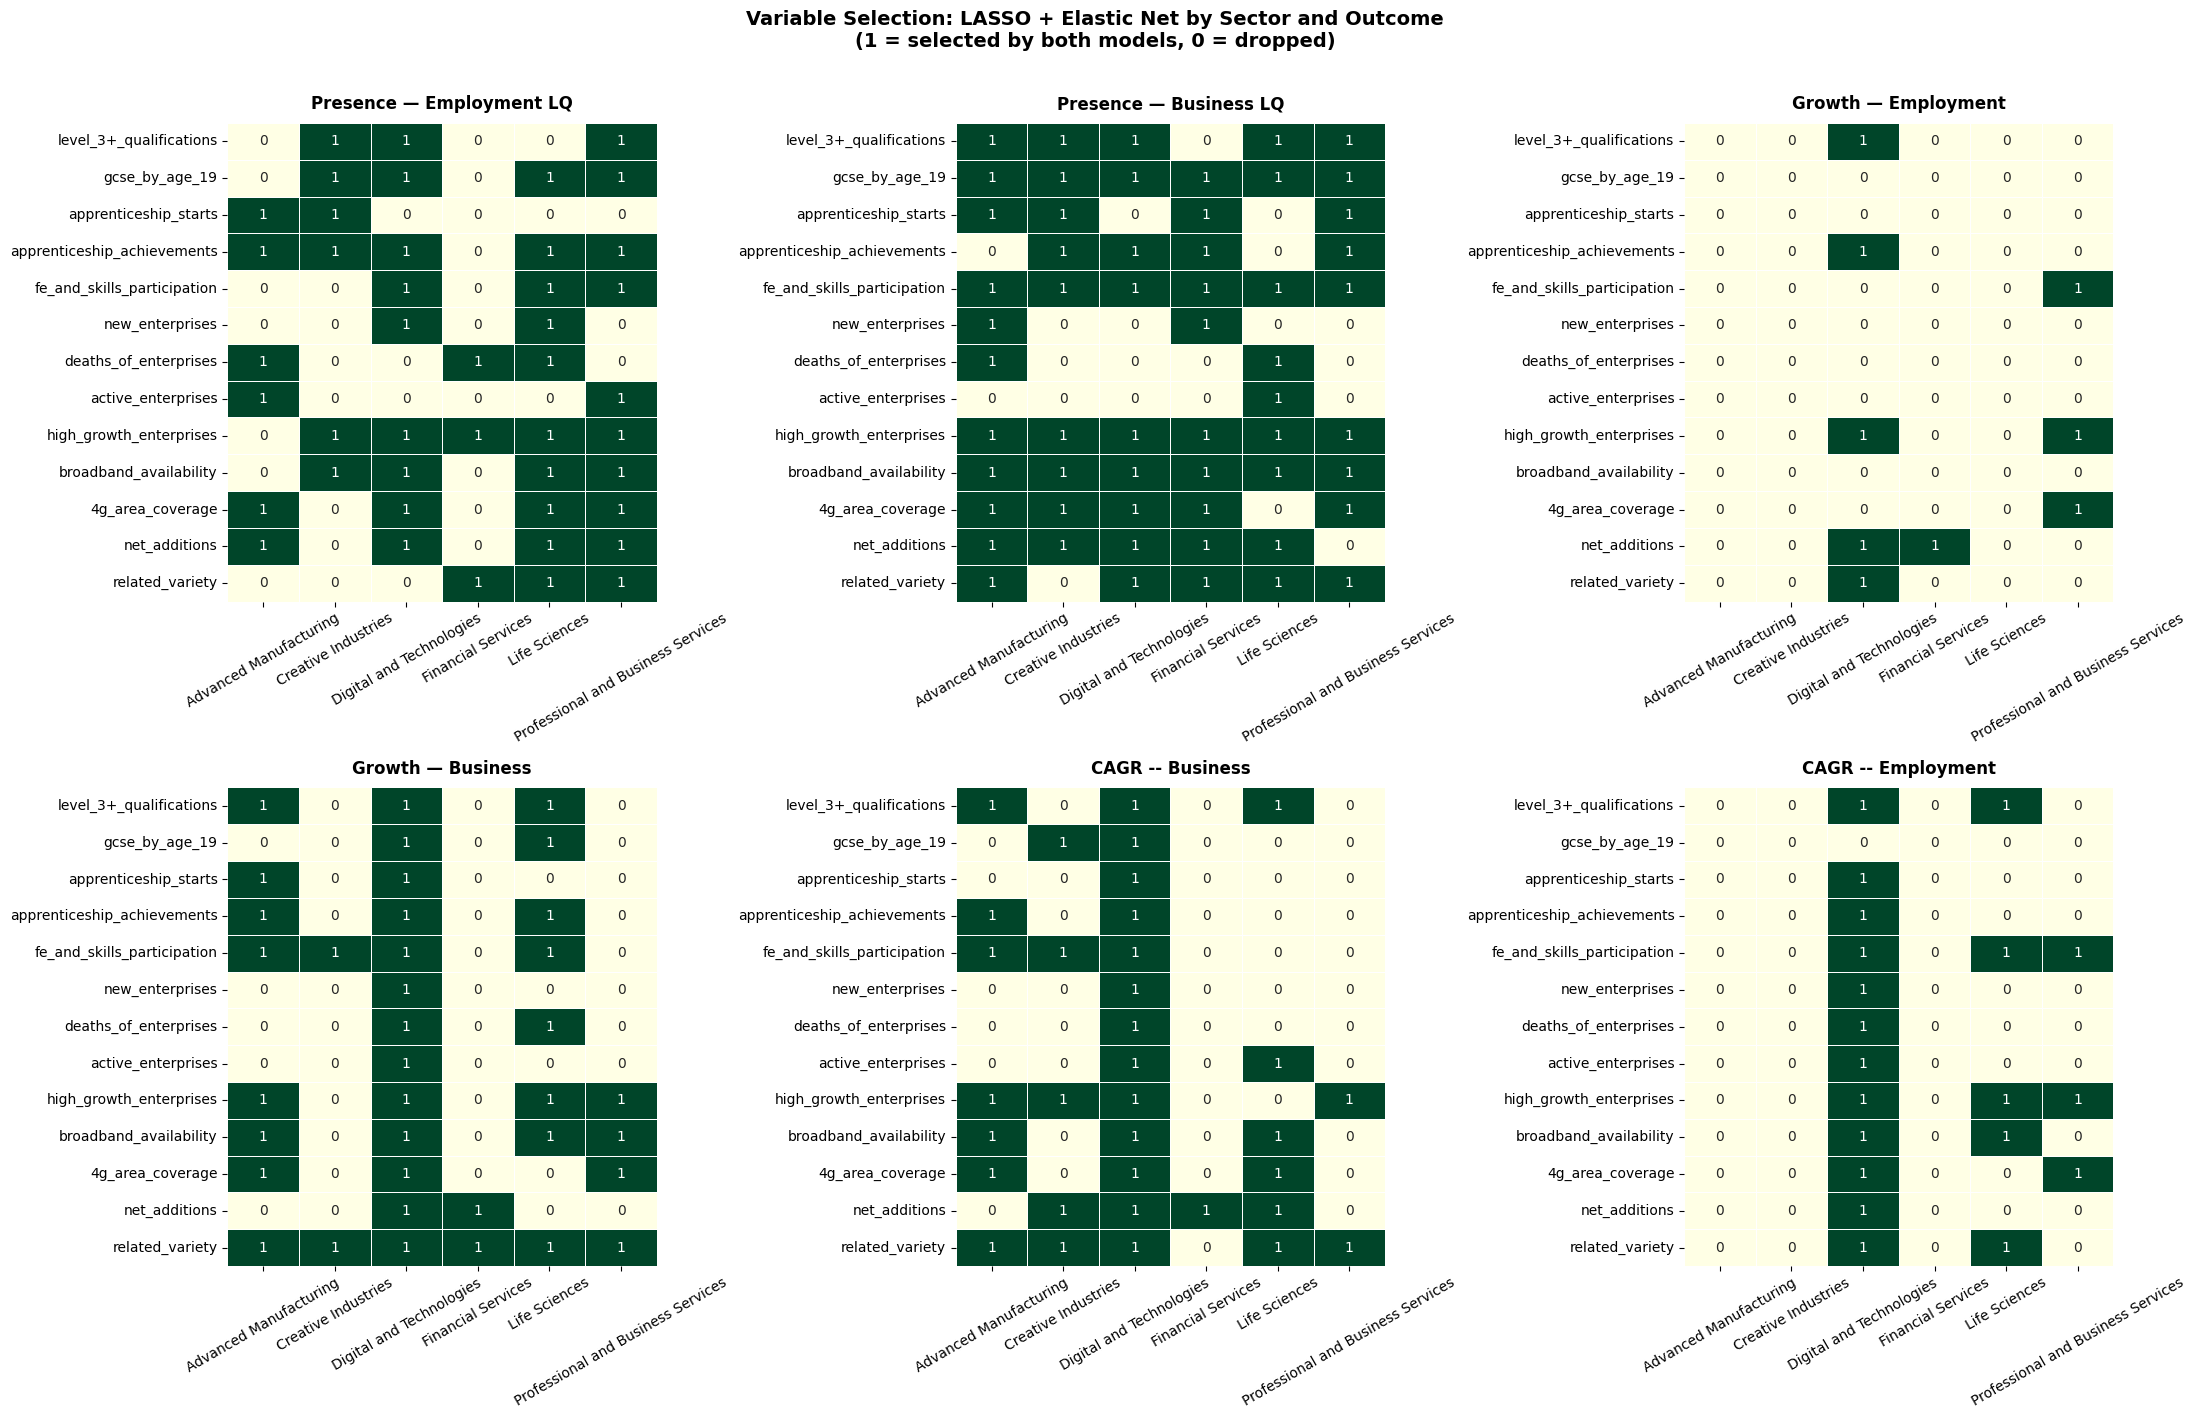

In [43]:
import math

# ============================================================
# PLOT 1: HEATMAP — VARIABLE SELECTION BY SECTOR × OUTCOME
# ============================================================

n_outcomes = len(OUTCOMES)
n_cols     = 3
n_rows     = math.ceil(n_outcomes / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 7))
axes      = axes.flatten()

for ax_idx, (y_col, outcome_label) in enumerate(OUTCOMES.items()):
    ax = axes[ax_idx]

    subset = selection_df[selection_df["outcome"] == y_col]
    pivot  = subset.pivot(index="variable", columns="sector", values="selected")
    pivot  = pivot.reindex(columns=SECTORS, index=PREDICTORS).fillna(0).astype(int)

    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt="d",
        cmap="YlGn",
        linewidths=0.5,
        linecolor="white",
        cbar=False,
        vmin=0, vmax=1,
    )
    ax.set_title(outcome_label, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

# Hide unused panels
for i in range(n_outcomes, len(axes)):
    axes[i].set_visible(False)

plt.suptitle(
    "Variable Selection: LASSO + Elastic Net by Sector and Outcome\n"
    "(1 = selected by both models, 0 = dropped)",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_selection_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()




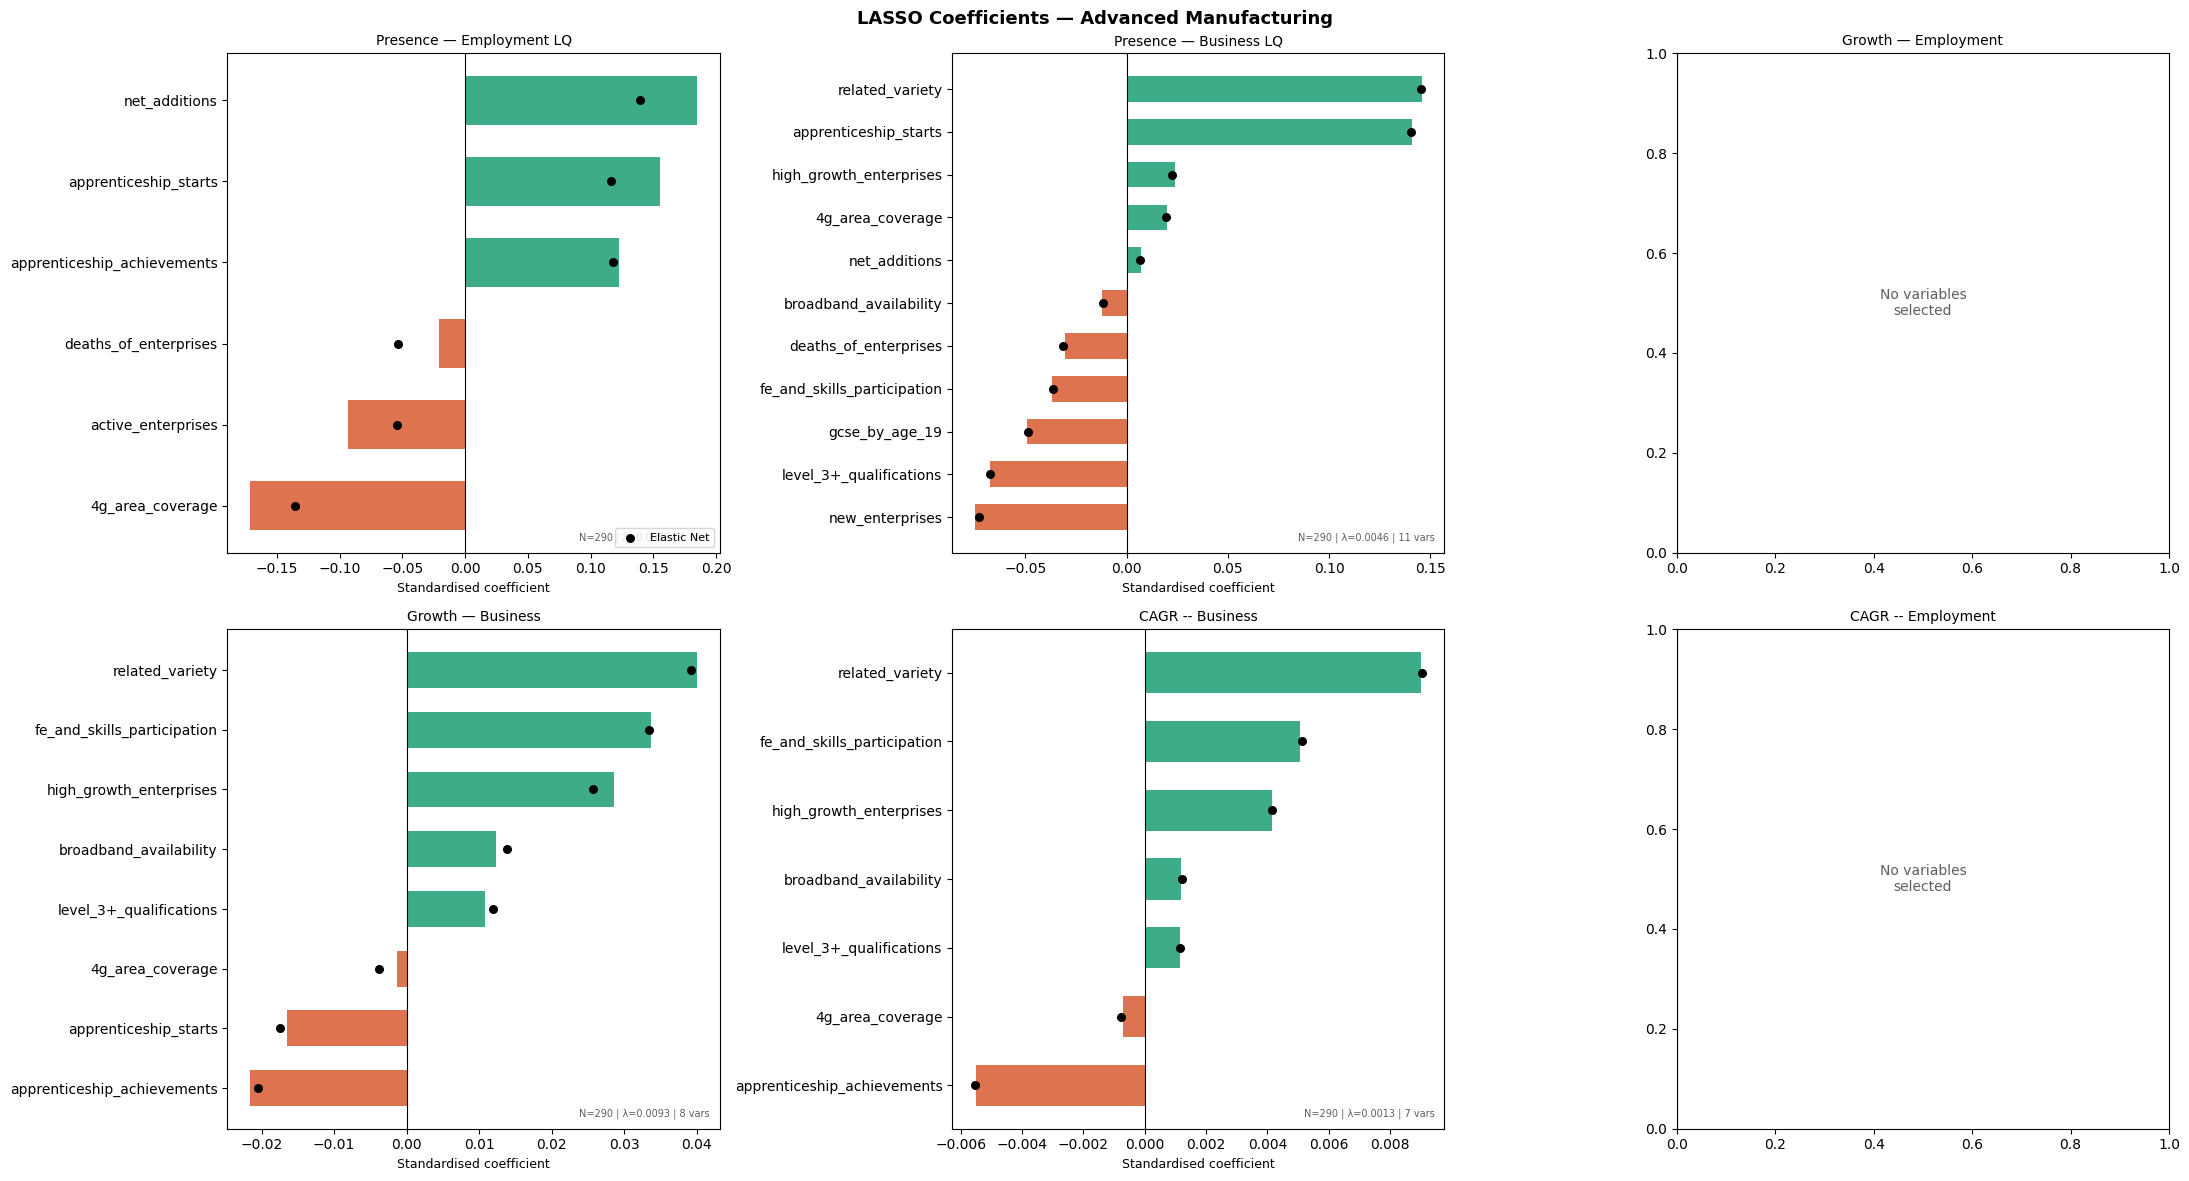

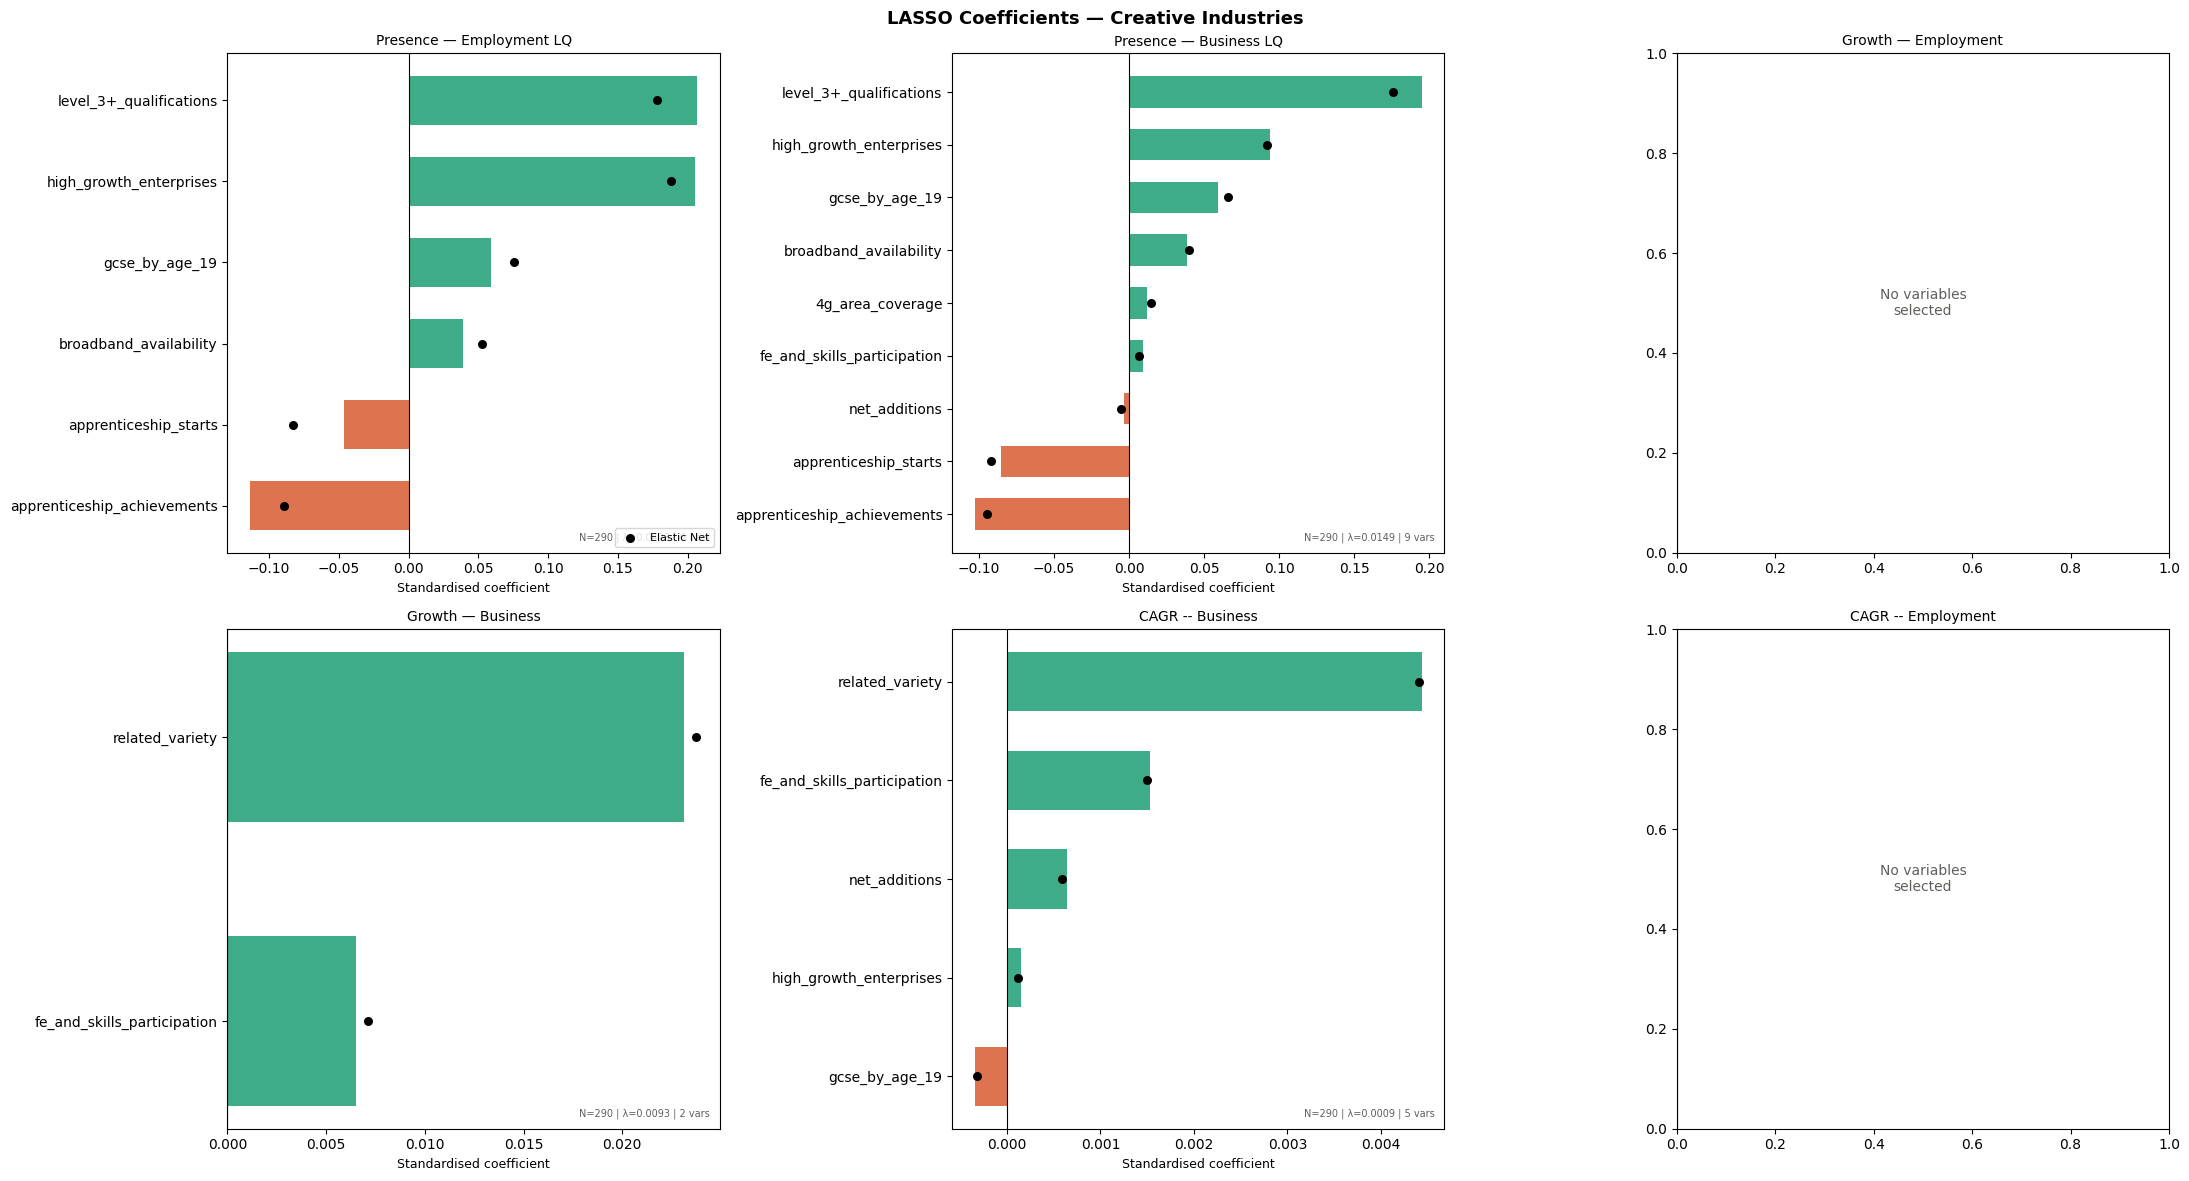

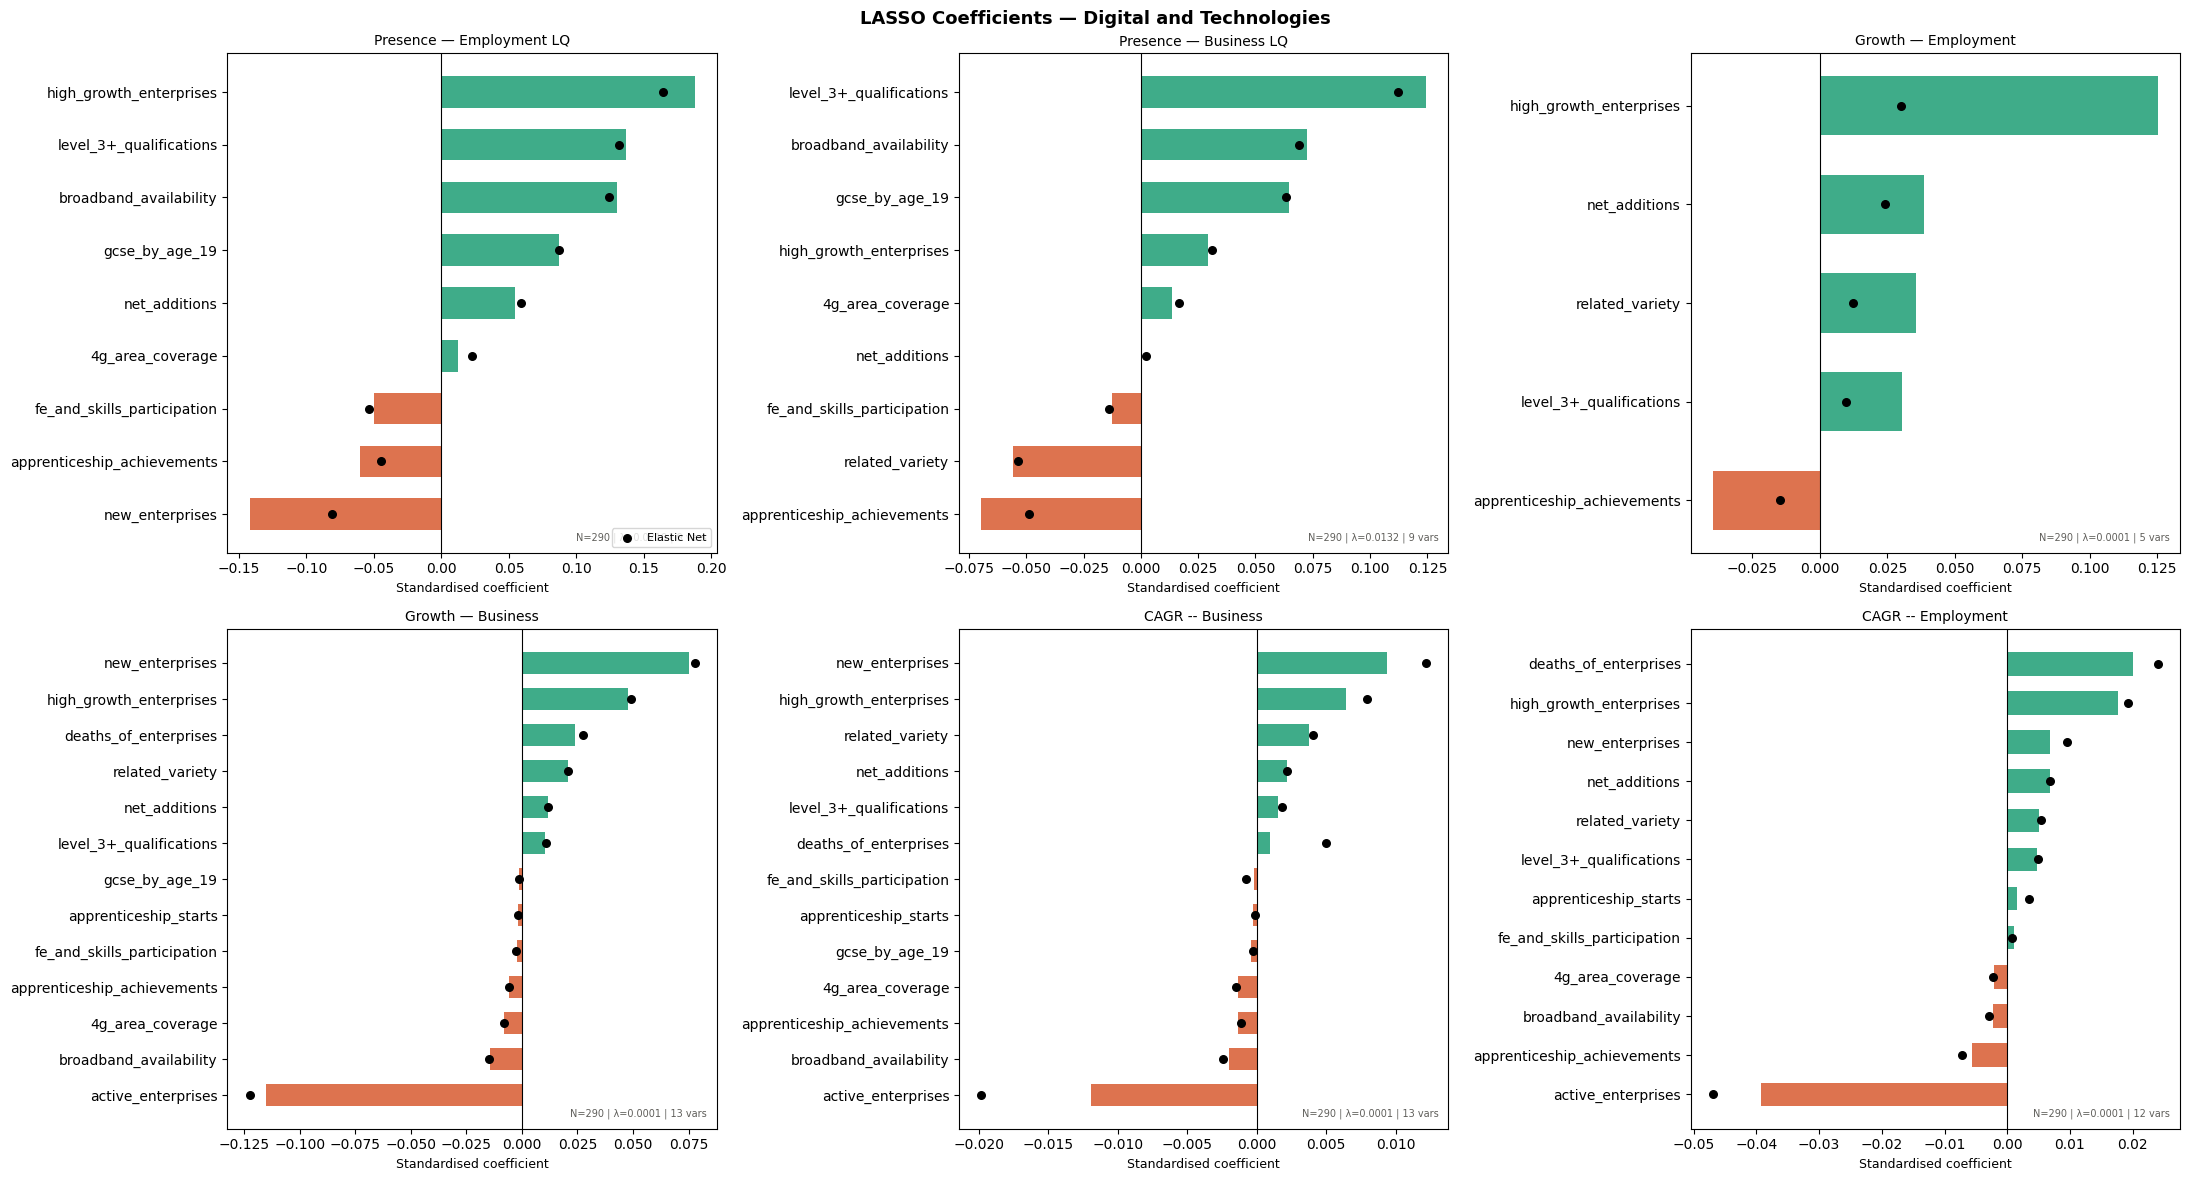

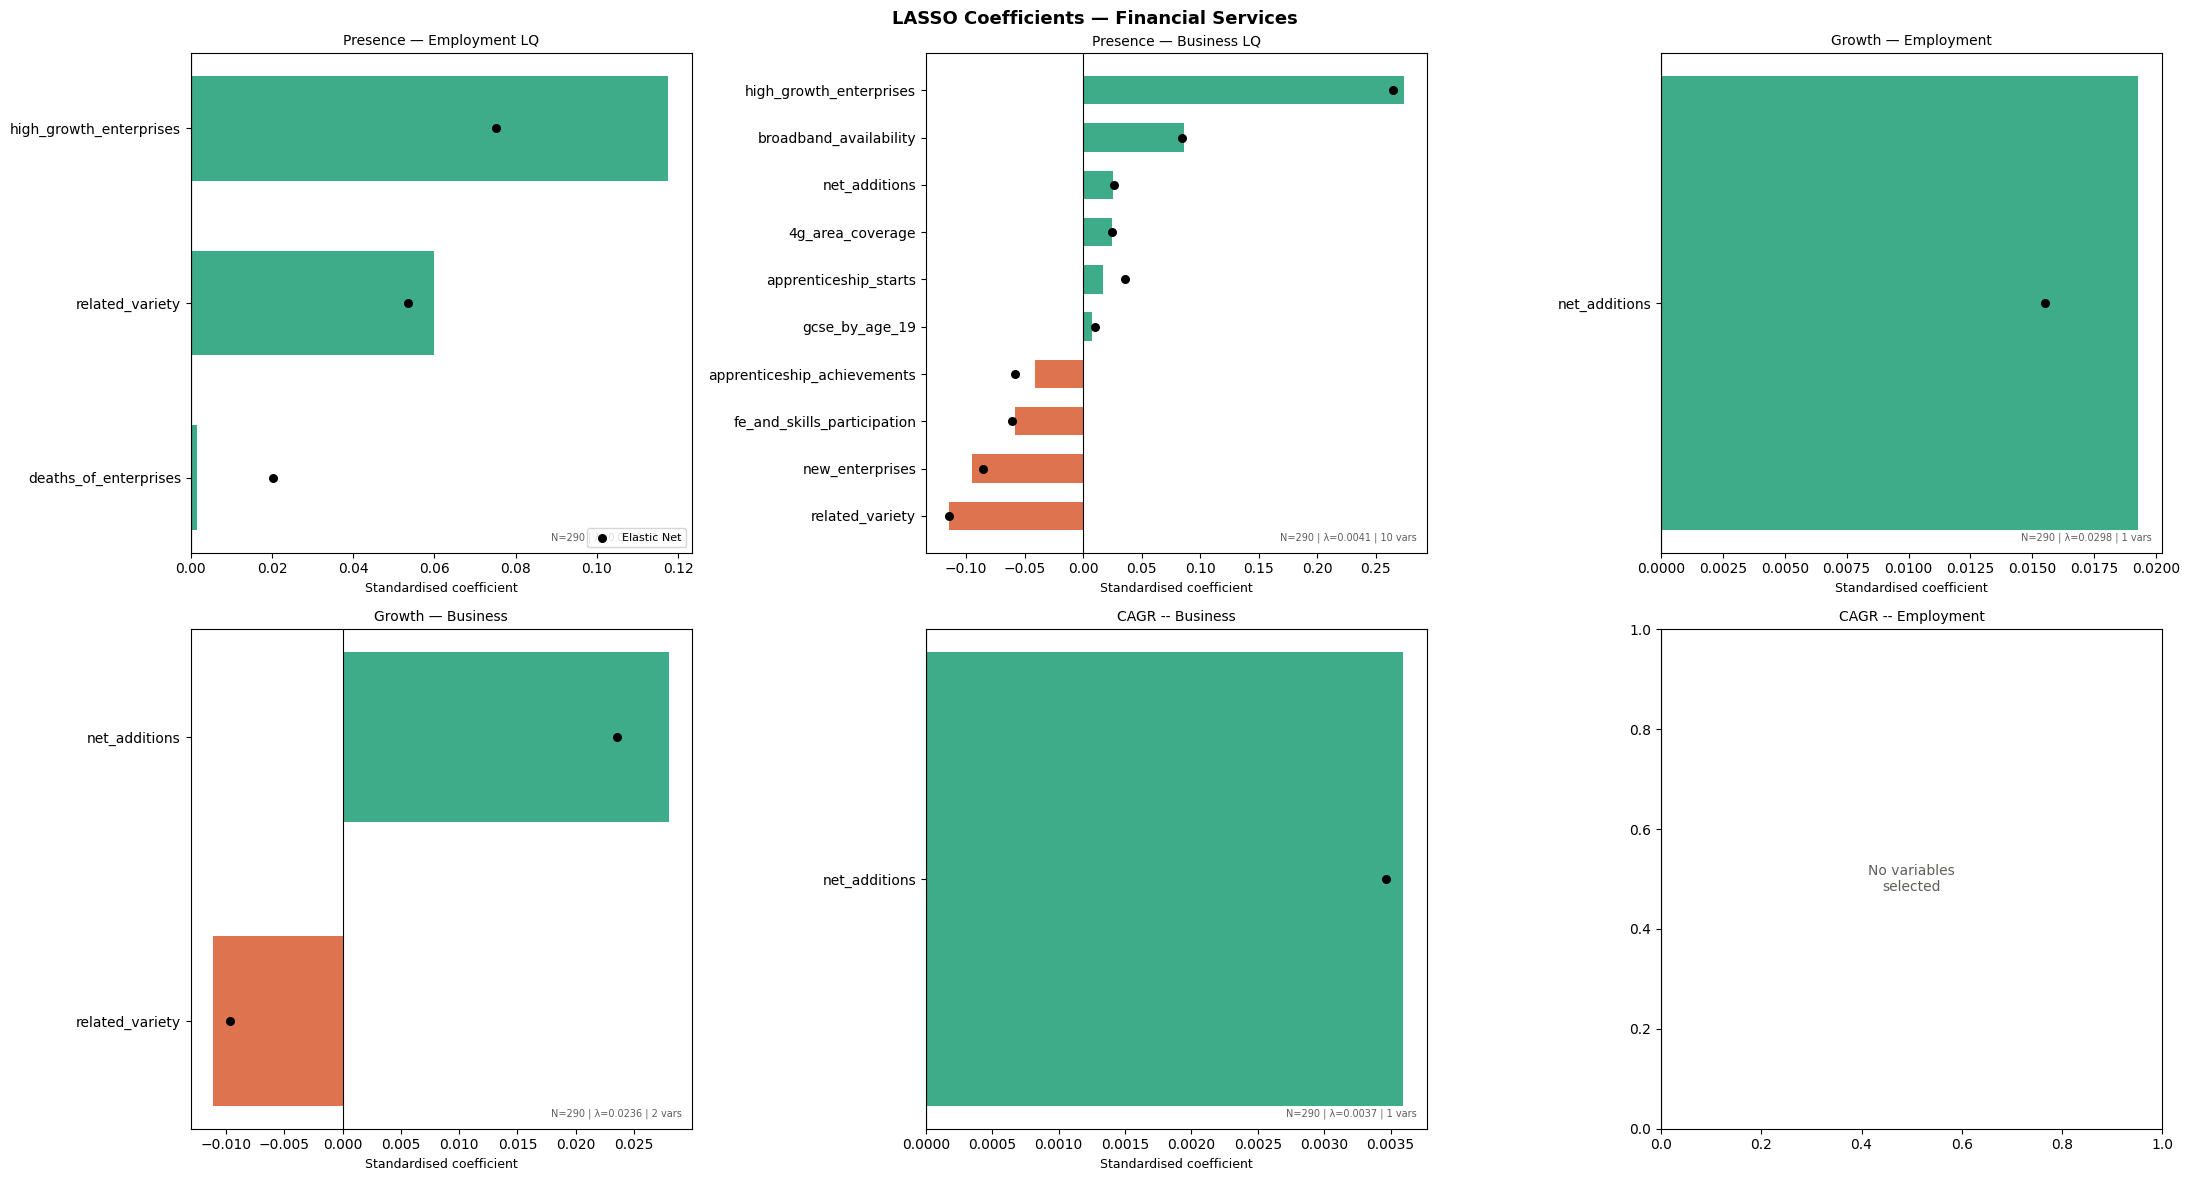

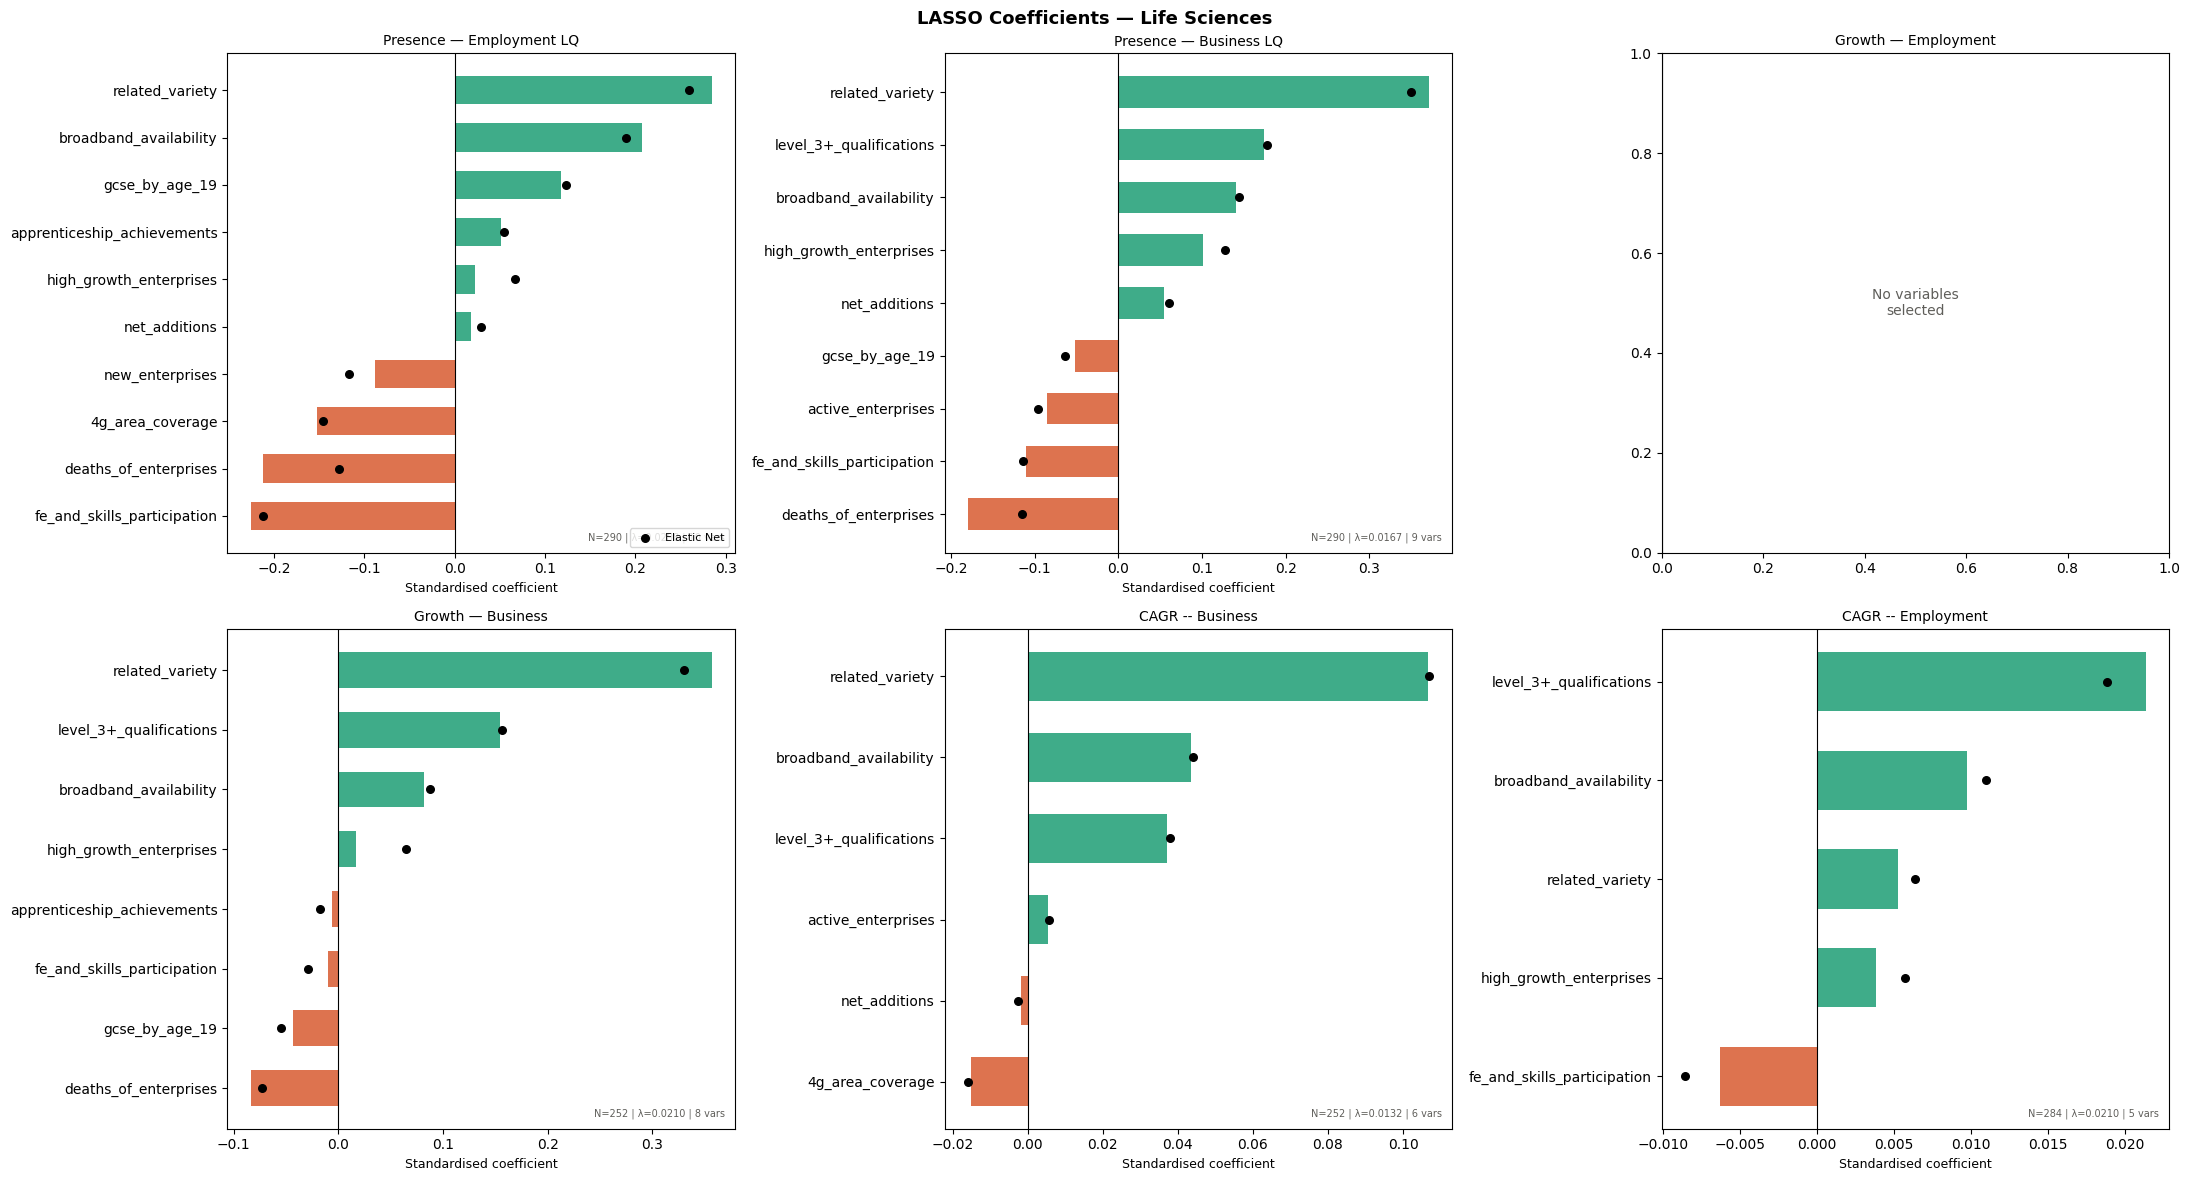

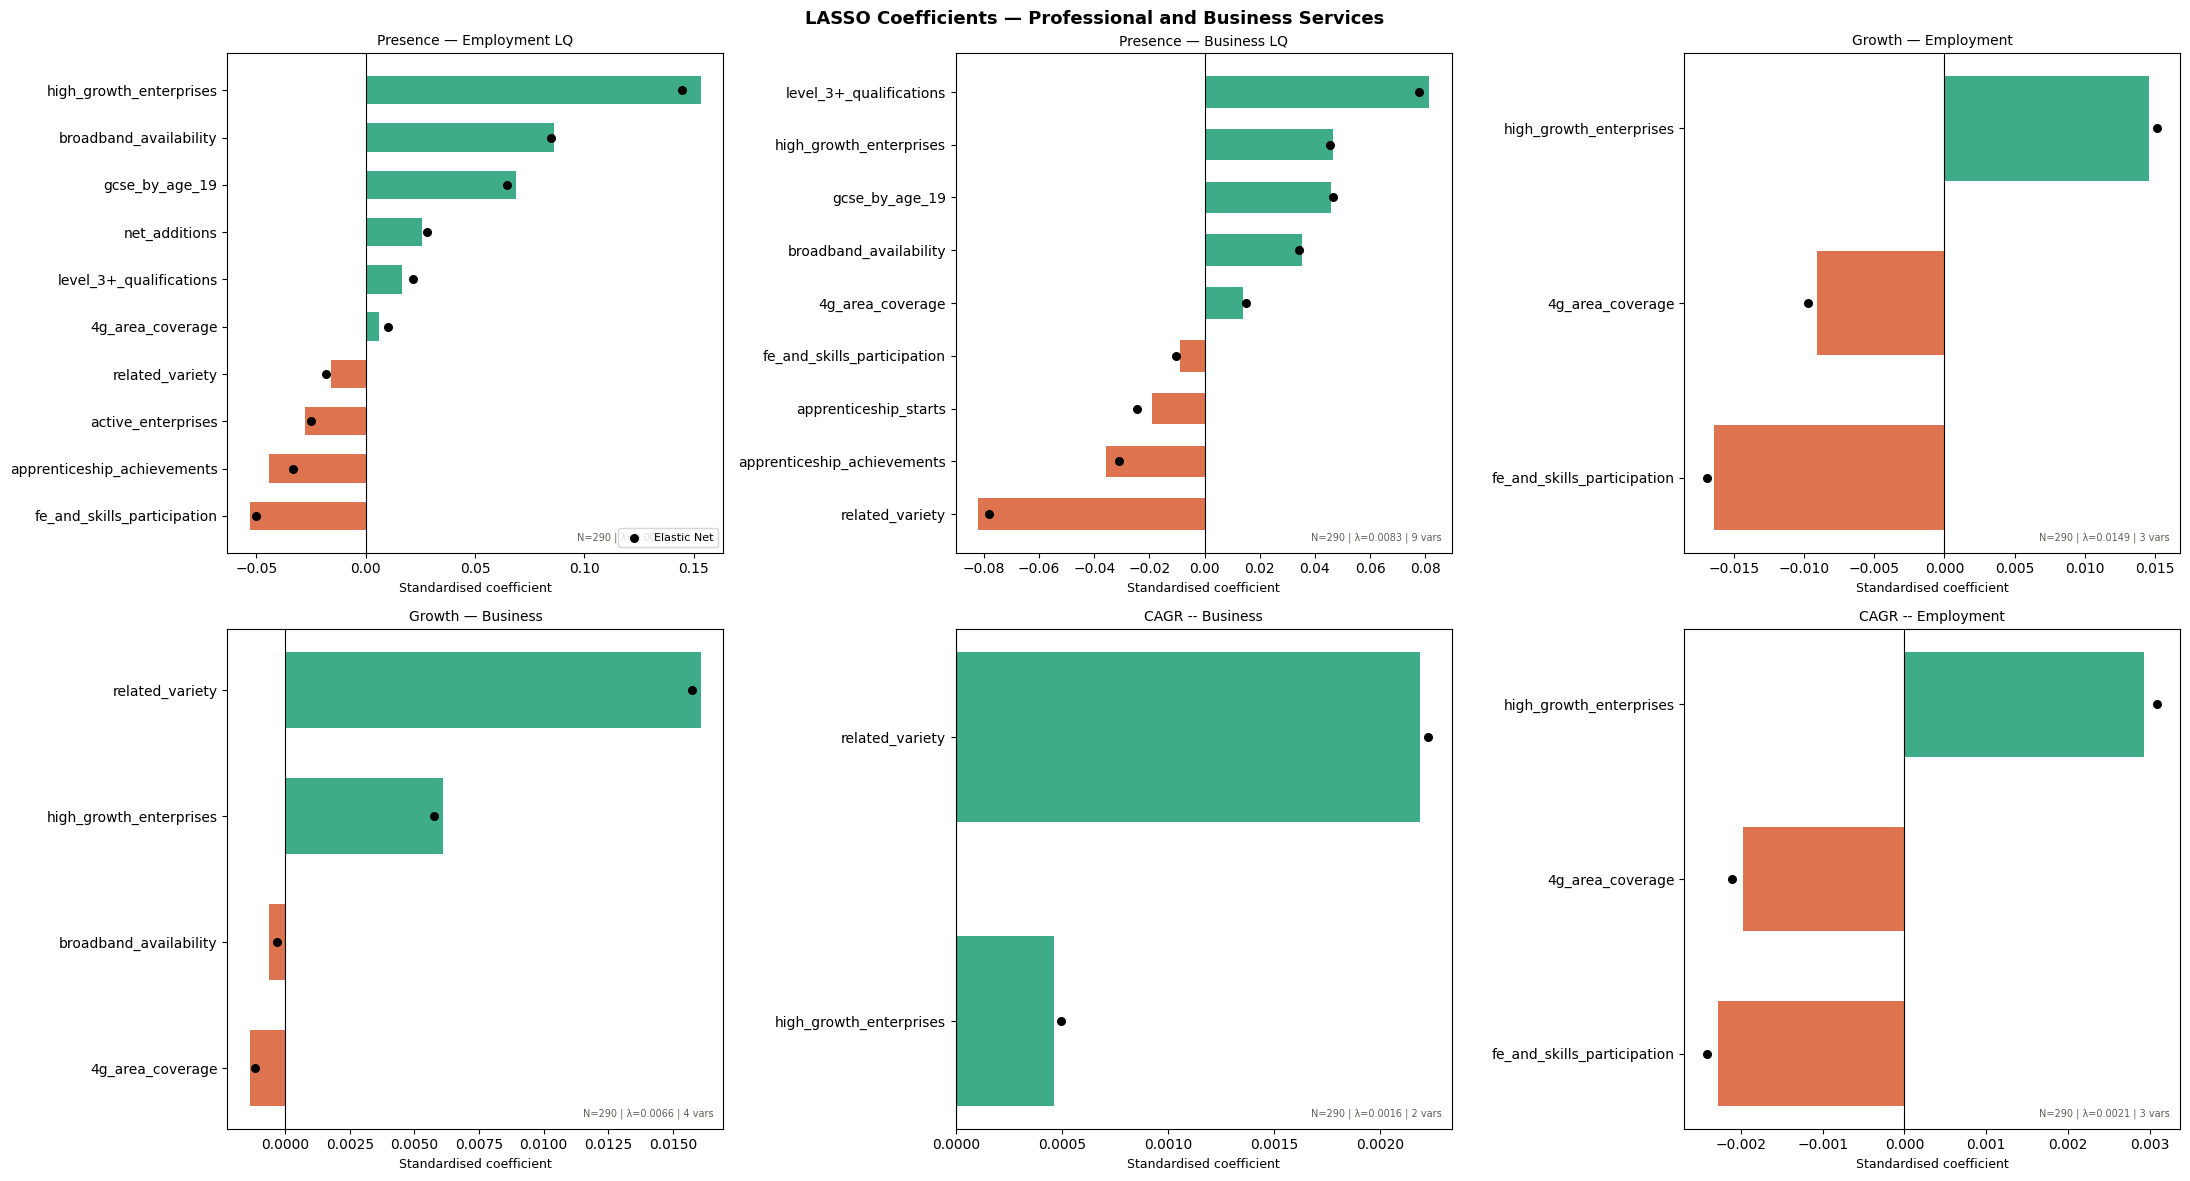

In [44]:
# ============================================================
# PLOT 2: COEFFICIENT PLOTS — ONE PER SECTOR
# ============================================================

for sector in SECTORS:

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(22, n_rows * 6),
                             sharey=False)
    axes = axes.flatten()
    fig.suptitle(f"LASSO Coefficients — {sector}",
                 fontsize=13, fontweight="bold")

    for ax_idx, (y_col, outcome_label) in enumerate(OUTCOMES.items()):
        ax = axes[ax_idx]

        if (sector, y_col) not in all_models:
            ax.text(0.5, 0.5, "Insufficient data",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(outcome_label, fontsize=10)
            continue

        res = all_models[(sector, y_col)]["results"]
        sel = res[res["selected_both"]].sort_values("lasso_coef")

        if sel.empty:
            ax.text(0.5, 0.5, "No variables\nselected",
                    ha="center", va="center", transform=ax.transAxes,
                    color=GRAY, fontsize=10)
            ax.set_title(outcome_label, fontsize=10)
            ax.axvline(0, color="black", linewidth=0.8)
            continue

        colors = [CORAL if c < 0 else TEAL for c in sel["lasso_coef"]]
        ax.barh(sel["variable"], sel["lasso_coef"],
                color=colors, alpha=0.85, height=0.6)
        ax.scatter(sel["enet_coef"], sel["variable"],
                   color="black", zorder=5, s=30,
                   label="Elastic Net")
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(outcome_label, fontsize=10)
        ax.set_xlabel("Standardised coefficient", fontsize=9)

        n     = all_models[(sector, y_col)]["n"]
        lam   = all_models[(sector, y_col)]["lambda_lasso"]
        n_sel = all_models[(sector, y_col)]["n_selected"]
        ax.text(0.98, 0.02,
                f"N={n} | λ={lam:.4f} | {n_sel} vars",
                transform=ax.transAxes, fontsize=7,
                ha="right", va="bottom", color=GRAY)

        if ax_idx == 0:
            ax.legend(fontsize=8, loc="lower right")

    # Hide unused panels
    for i in range(n_outcomes, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    sector_slug = sector.lower().replace(" ", "_").replace("&", "and")
    plt.savefig(OUTPUT_DIR / f"02_coefs_{sector_slug}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

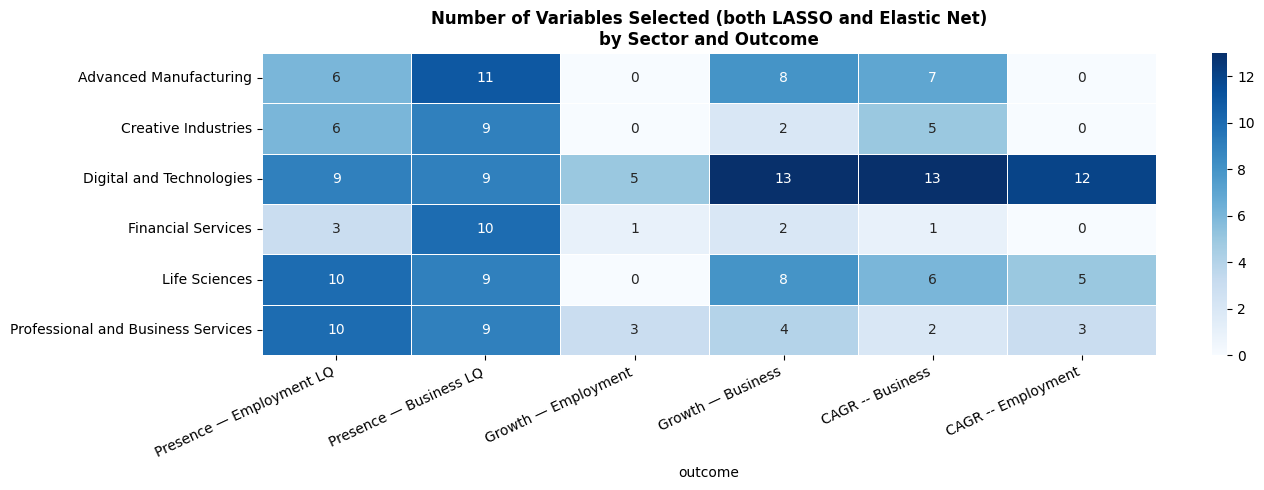


✅ All outputs saved to: output\sector_models
   01_selection_heatmap.png  — variable selection per sector/outcome
   02_coefs_<sector>.png     — coefficient plots per sector (6 files)
   03_selection_counts.png   — count of selected variables
   model_summary.csv         — lambda, l1_ratio, N per model
   all_coefficients.csv      — full coefficient table


In [45]:
# ── PLOT 3: COUNT OF SELECTED VARIABLES PER SECTOR × OUTCOME ─

count_pivot = summary_df.pivot(
    index="sector", columns="outcome", values="n_selected"
).reindex(columns=list(OUTCOMES.keys()), index=SECTORS).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(14, 5))  # wider to fit 6 outcomes
sns.heatmap(
    count_pivot,
    ax=ax,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    vmin=0,
    vmax=len(PREDICTORS),
)
ax.set_title(
    "Number of Variables Selected (both LASSO and Elastic Net)\nby Sector and Outcome",
    fontsize=12, fontweight="bold"
)
# Safe xticklabels — only label columns that exist in OUTCOMES
ax.set_xticklabels(
    [OUTCOMES.get(c, c) for c in count_pivot.columns],
    rotation=25, ha="right"
)
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_selection_counts.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ All outputs saved to:", OUTPUT_DIR)
print("   01_selection_heatmap.png  — variable selection per sector/outcome")
print("   02_coefs_<sector>.png     — coefficient plots per sector (6 files)")
print("   03_selection_counts.png   — count of selected variables")
print("   model_summary.csv         — lambda, l1_ratio, N per model")
print("   all_coefficients.csv      — full coefficient table")

In [47]:
# ── NATIONAL CONTRIBUTION BY SECTOR ──────────────────────────

# Use the end year only
END_YEAR = df["year"].max()
df_end   = df[df["year"] == END_YEAR].copy()

# 1. Total employment and businesses per sector (national)
national = (
    df_end.groupby("is8_sector", observed=True)
    .agg(
        total_employees   = ("employees",  "sum"),
        total_businesses  = ("businesses", "sum"),
        n_lads            = ("geography_code", "nunique"),
    )
    .reset_index()
    .sort_values("total_employees", ascending=False)
)

# 2. Add share of total
national["emp_share_%"]  = (national["total_employees"]  / national["total_employees"].sum()  * 100).round(1)
national["bus_share_%"]  = (national["total_businesses"] / national["total_businesses"].sum() * 100).round(1)

print(national.to_string(index=False))

                        is8_sector  total_employees  total_businesses  n_lads  emp_share_%  bus_share_%
Professional and Business Services        5718640.0          842300.0     350         46.5    53.400002
          Digital and Technologies        2267205.0          291630.0     350         18.5    18.500000
                Financial Services        1720315.0          105070.0     350         14.0     6.700000
               Creative Industries        1650315.0          308525.0     350         13.4    19.600000
            Advanced Manufacturing         802915.0           27020.0     350          6.5     1.700000
                     Life Sciences         108075.0            3560.0     350          0.9     0.200000
                           Defence          17670.0              25.0     350          0.1     0.000000


In [48]:
# ============================================================
# MÉTRICAS DE EVALUACIÓN — LASSO POR SECTOR Y OUTCOME
# R², RMSE, MAE — calculadas con cross-validation
# ============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path

OUTPUT_DIR = Path("output/sector_models")

# ── FUNCIÓN PRINCIPAL ─────────────────────────────────────────

def compute_lasso_metrics(sector_df, y_col, sector_name, outcome_label):
    """
    Calcula R², RMSE y MAE para LASSO usando cross-validation.
    
    Usa el mismo lambda óptimo encontrado por LassoCV,
    luego evalúa el modelo con CV para obtener métricas
    comparables con Random Forest.
    """
    cols     = PREDICTORS + [y_col]
    model_df = sector_df[cols].dropna()
    n        = len(model_df)

    if n < 30:
        print(f"  ⚠ {sector_name} | {outcome_label}: N={n} — skipped")
        return None

    # Estandarizar X
    X = StandardScaler().fit_transform(model_df[PREDICTORS].values.astype(float))
    y = model_df[y_col].values.astype(float)

    # Cross-validation setup
    n_splits = min(5, n // 10)
    n_splits = max(n_splits, 3)
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # ── Fit LASSO con lambda óptimo ───────────────────────────
    lasso = LassoCV(
        alphas=np.logspace(-4, 2, 100),
        cv=cv,
        max_iter=10_000,
        random_state=42
    )
    lasso.fit(X, y)

    # ── Métricas via cross-validation ─────────────────────────
    # Esto asegura que las métricas son out-of-sample
    # (no calculadas sobre los mismos datos de entrenamiento)
    
    r2_scores   = cross_val_score(lasso, X, y, cv=cv, scoring="r2")
    rmse_scores = cross_val_score(lasso, X, y, cv=cv,
                                  scoring="neg_root_mean_squared_error")
    mae_scores  = cross_val_score(lasso, X, y, cv=cv,
                                  scoring="neg_mean_absolute_error")

    # ── Métricas in-sample (para referencia) ──────────────────
    y_pred      = lasso.predict(X)
    r2_insample = r2_score(y, y_pred)
    n_selected  = (lasso.coef_ != 0).sum()

    print(f"  ✓ {sector_name} | {outcome_label}: "
          f"N={n} | CV R²={r2_scores.mean():.3f} | "
          f"RMSE={-rmse_scores.mean():.3f} | "
          f"vars={n_selected}")

    return {
        "sector":          sector_name,
        "outcome":         y_col,
        "outcome_label":   outcome_label,
        "n":               n,
        "n_selected":      int(n_selected),
        "lambda":          round(lasso.alpha_, 6),
        # Cross-validation metrics (out-of-sample) ← usar estas para comparar
        "cv_r2_mean":      round(r2_scores.mean(),    3),
        "cv_r2_std":       round(r2_scores.std(),     3),
        "cv_rmse_mean":    round(-rmse_scores.mean(), 3),
        "cv_rmse_std":     round(-rmse_scores.std(),  3),
        "cv_mae_mean":     round(-mae_scores.mean(),  3),
        "cv_mae_std":      round(-mae_scores.std(),   3),
        # In-sample R² (para comparar con OLS R²)
        "r2_insample":     round(r2_insample,         3),
    }

# ── CORRER PARA TODOS LOS SECTORES Y OUTCOMES ─────────────────

print("\n" + "="*65)
print("LASSO — MÉTRICAS DE EVALUACIÓN")
print("="*65)

metrics_rows = []

for sector in SECTORS:
    sector_df = df_cs[df_cs["is8_sector"] == sector].copy()
    print(f"\n── {sector} ──")

    for y_col, outcome_label in OUTCOMES.items():
        result = compute_lasso_metrics(
            sector_df, y_col, sector, outcome_label
        )
        if result is not None:
            metrics_rows.append(result)

# ── TABLA RESUMEN ─────────────────────────────────────────────

metrics_df = pd.DataFrame(metrics_rows)

print("\n" + "="*65)
print("RESUMEN — CV METRICS POR SECTOR Y OUTCOME")
print("="*65)

# Tabla legible
display_cols = [
    "sector", "outcome", "n", "n_selected",
    "cv_r2_mean", "cv_rmse_mean", "cv_mae_mean", "lambda"
]
print(metrics_df[display_cols].to_string(index=False))

# ── EXPORTAR ──────────────────────────────────────────────────
metrics_df.to_csv(OUTPUT_DIR / "lasso_evaluation_metrics.csv", index=False)
print(f"\n✅ Métricas guardadas en: {OUTPUT_DIR / 'lasso_evaluation_metrics.csv'}")

# ── PIVOT TABLE — R² POR SECTOR × OUTCOME ─────────────────────
print("\n── R² (cross-validation) por sector y outcome ──")
r2_pivot = metrics_df.pivot(
    index="sector", columns="outcome", values="cv_r2_mean"
).reindex(columns=list(OUTCOMES.keys()), index=SECTORS).round(3)
print(r2_pivot.to_string())

print("\n── RMSE (cross-validation) por sector y outcome ──")
rmse_pivot = metrics_df.pivot(
    index="sector", columns="outcome", values="cv_rmse_mean"
).reindex(columns=list(OUTCOMES.keys()), index=SECTORS).round(3)
print(rmse_pivot.to_string())


LASSO — MÉTRICAS DE EVALUACIÓN

── Advanced Manufacturing ──
  ✓ Advanced Manufacturing | Presence — Employment LQ: N=290 | CV R²=-0.068 | RMSE=1.204 | vars=6
  ✓ Advanced Manufacturing | Presence — Business LQ: N=290 | CV R²=0.351 | RMSE=0.358 | vars=11
  ✓ Advanced Manufacturing | Growth — Employment: N=290 | CV R²=-0.048 | RMSE=0.394 | vars=0
  ✓ Advanced Manufacturing | Growth — Business: N=290 | CV R²=-0.135 | RMSE=0.272 | vars=8
  ✓ Advanced Manufacturing | CAGR -- Business: N=290 | CV R²=-0.053 | RMSE=0.039 | vars=7
  ✓ Advanced Manufacturing | CAGR -- Employment: N=290 | CV R²=-0.029 | RMSE=0.059 | vars=0

── Creative Industries ──
  ✓ Creative Industries | Presence — Employment LQ: N=290 | CV R²=0.269 | RMSE=0.586 | vars=6
  ✓ Creative Industries | Presence — Business LQ: N=290 | CV R²=0.598 | RMSE=0.315 | vars=9
  ✓ Creative Industries | Growth — Employment: N=290 | CV R²=-0.103 | RMSE=0.255 | vars=0
  ✓ Creative Industries | Growth — Business: N=290 | CV R²=0.011 | RMSE=0.1

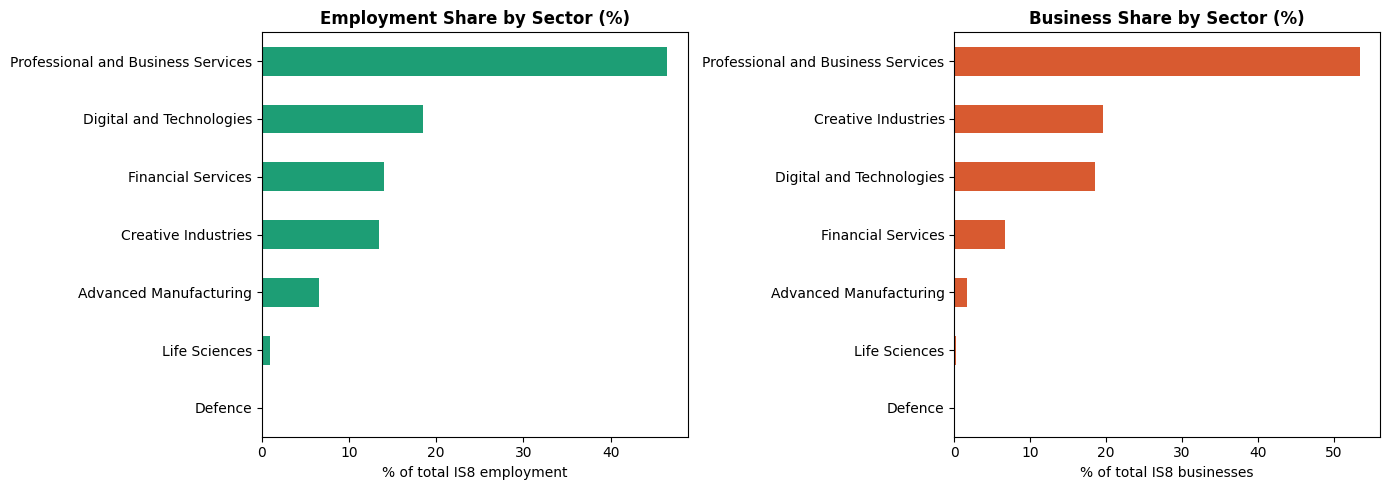

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Employment share
national.sort_values("emp_share_%").plot.barh(
    x="is8_sector", y="emp_share_%",
    ax=axes[0], color=TEAL, legend=False
)
axes[0].set_title("Employment Share by Sector (%)", fontweight="bold")
axes[0].set_xlabel("% of total IS8 employment")
axes[0].set_ylabel("")

# Business share
national.sort_values("bus_share_%").plot.barh(
    x="is8_sector", y="bus_share_%",
    ax=axes[1], color=CORAL, legend=False
)
axes[1].set_title("Business Share by Sector (%)", fontweight="bold")
axes[1].set_xlabel("% of total IS8 businesses")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "national_contribution_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
# ============================================================
# POST-SELECTION OLS
# Runs OLS on variables selected by both LASSO and Elastic Net
# Uses LAD-clustered standard errors
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")


POST-SELECTION OLS

── Advanced Manufacturing | Presence — Employment LQ ──
  ✓ Advanced Manufacturing | Presence — Employment LQ: N=291 | R²=0.199 | Sig(5%): 1/6

── Advanced Manufacturing | Presence — Business LQ ──
  ✓ Advanced Manufacturing | Presence — Business LQ: N=290 | R²=0.401 | Sig(5%): 4/11

── Advanced Manufacturing | Growth — Employment ──
  ⚠ Advanced Manufacturing | Growth — Employment: no vars selected — skipped

── Advanced Manufacturing | Growth — Business ──
  ✓ Advanced Manufacturing | Growth — Business: N=290 | R²=0.127 | Sig(5%): 2/8

── Creative Industries | Presence — Employment LQ ──
  ✓ Creative Industries | Presence — Employment LQ: N=290 | R²=0.508 | Sig(5%): 4/6

── Creative Industries | Presence — Business LQ ──
  ✓ Creative Industries | Presence — Business LQ: N=290 | R²=0.692 | Sig(5%): 3/9

── Creative Industries | Growth — Employment ──
  ⚠ Creative Industries | Growth — Employment: no vars selected — skipped

── Creative Industries | Growth — Busine

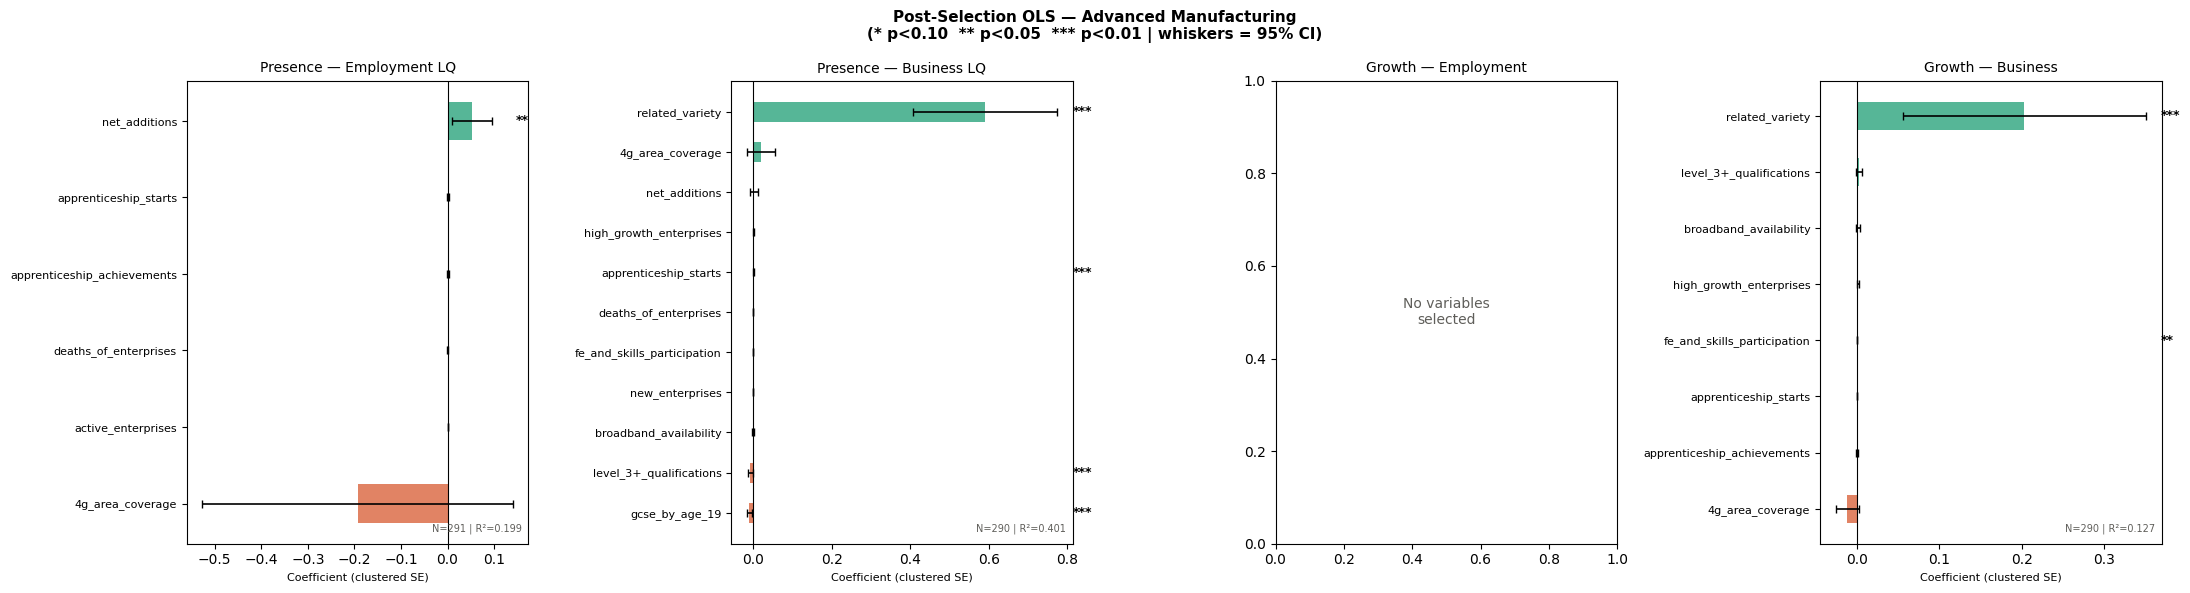

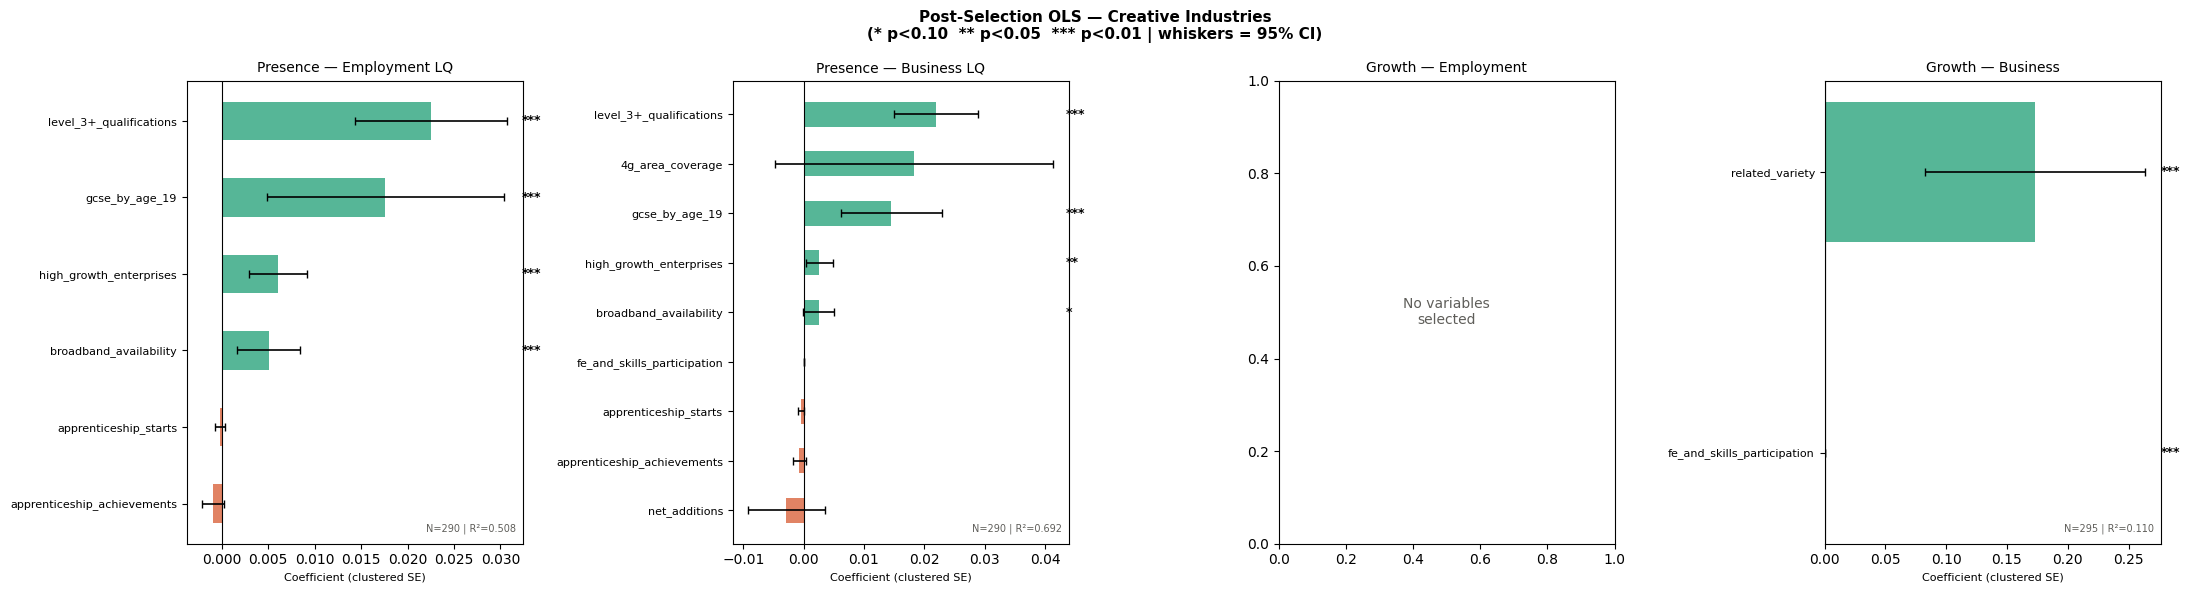

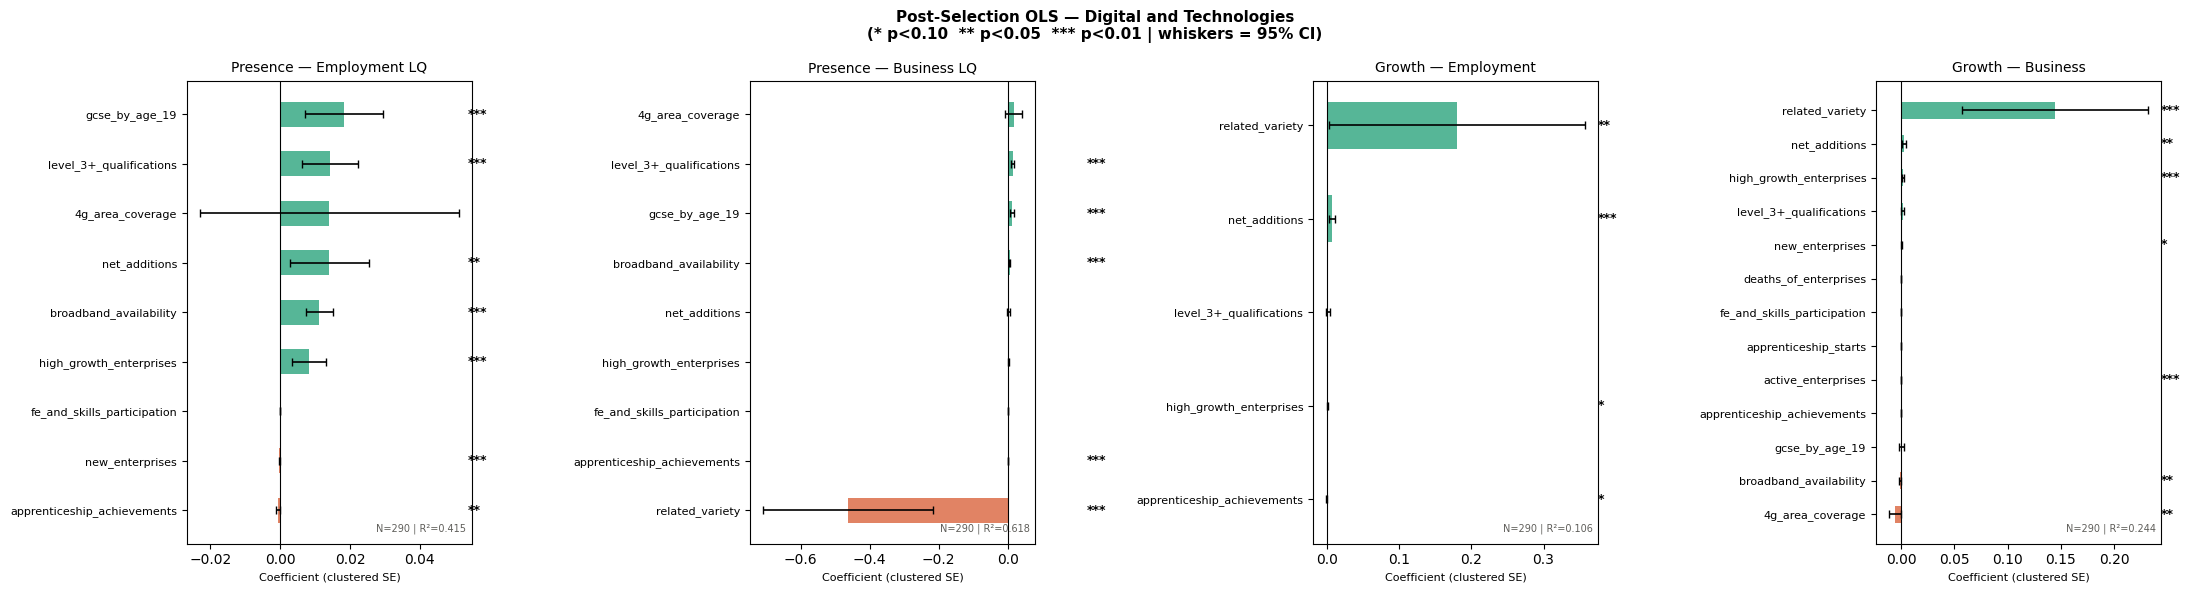

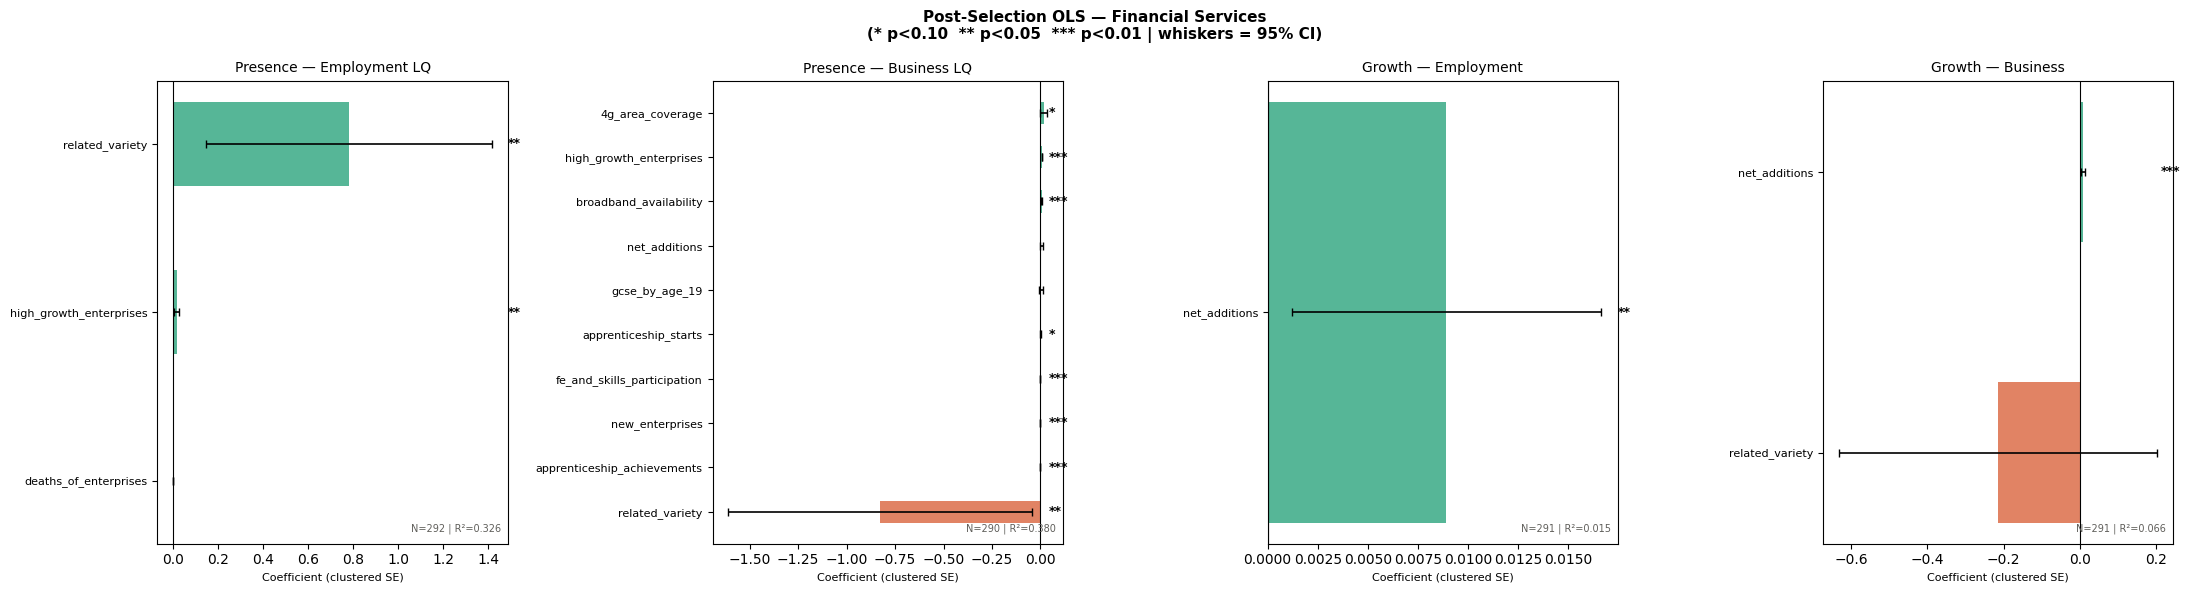

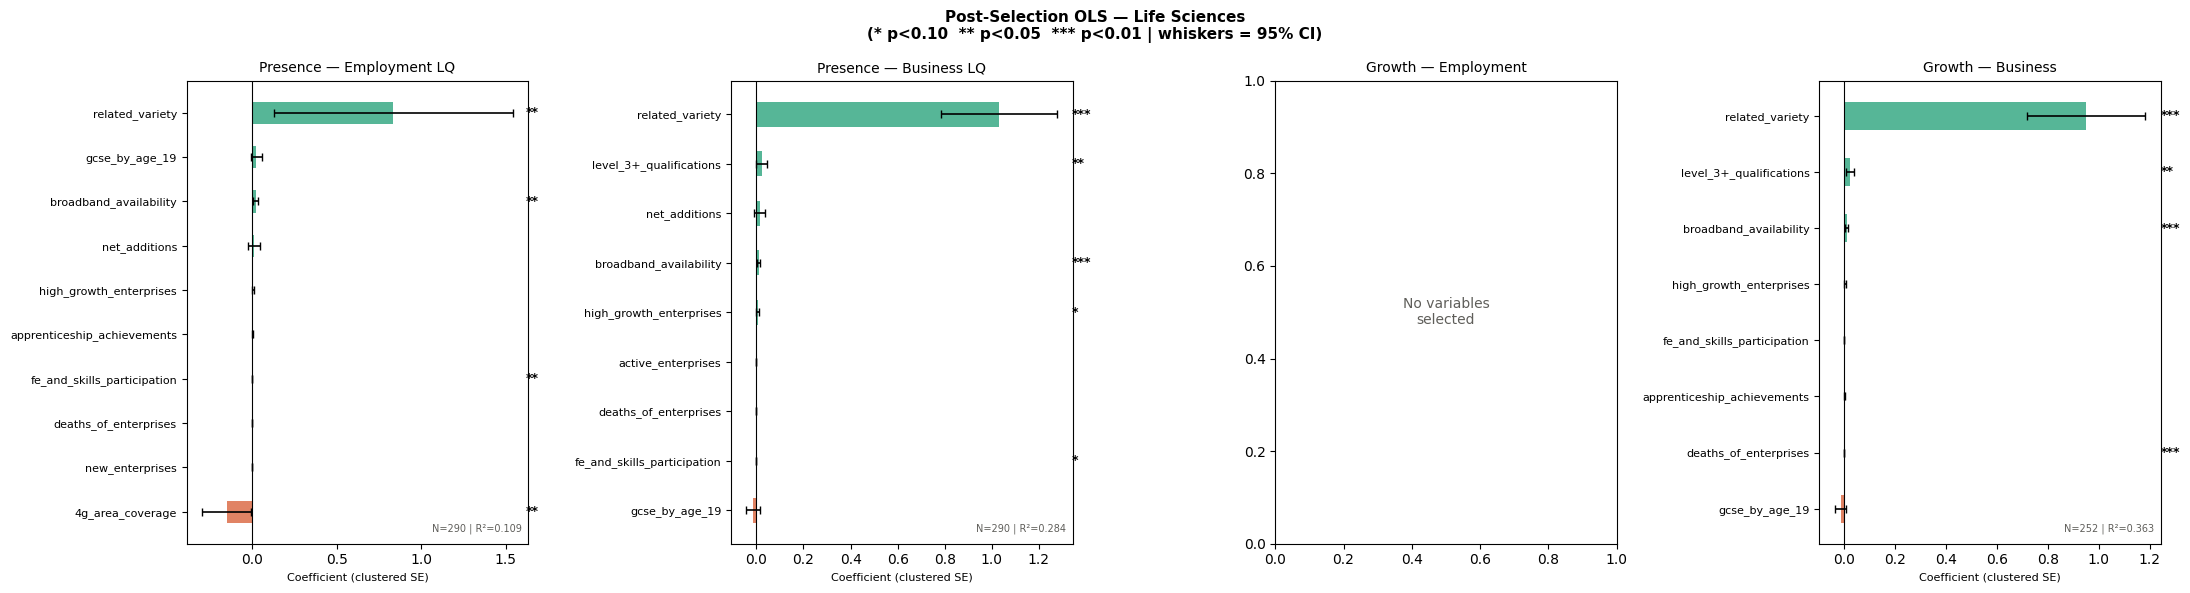

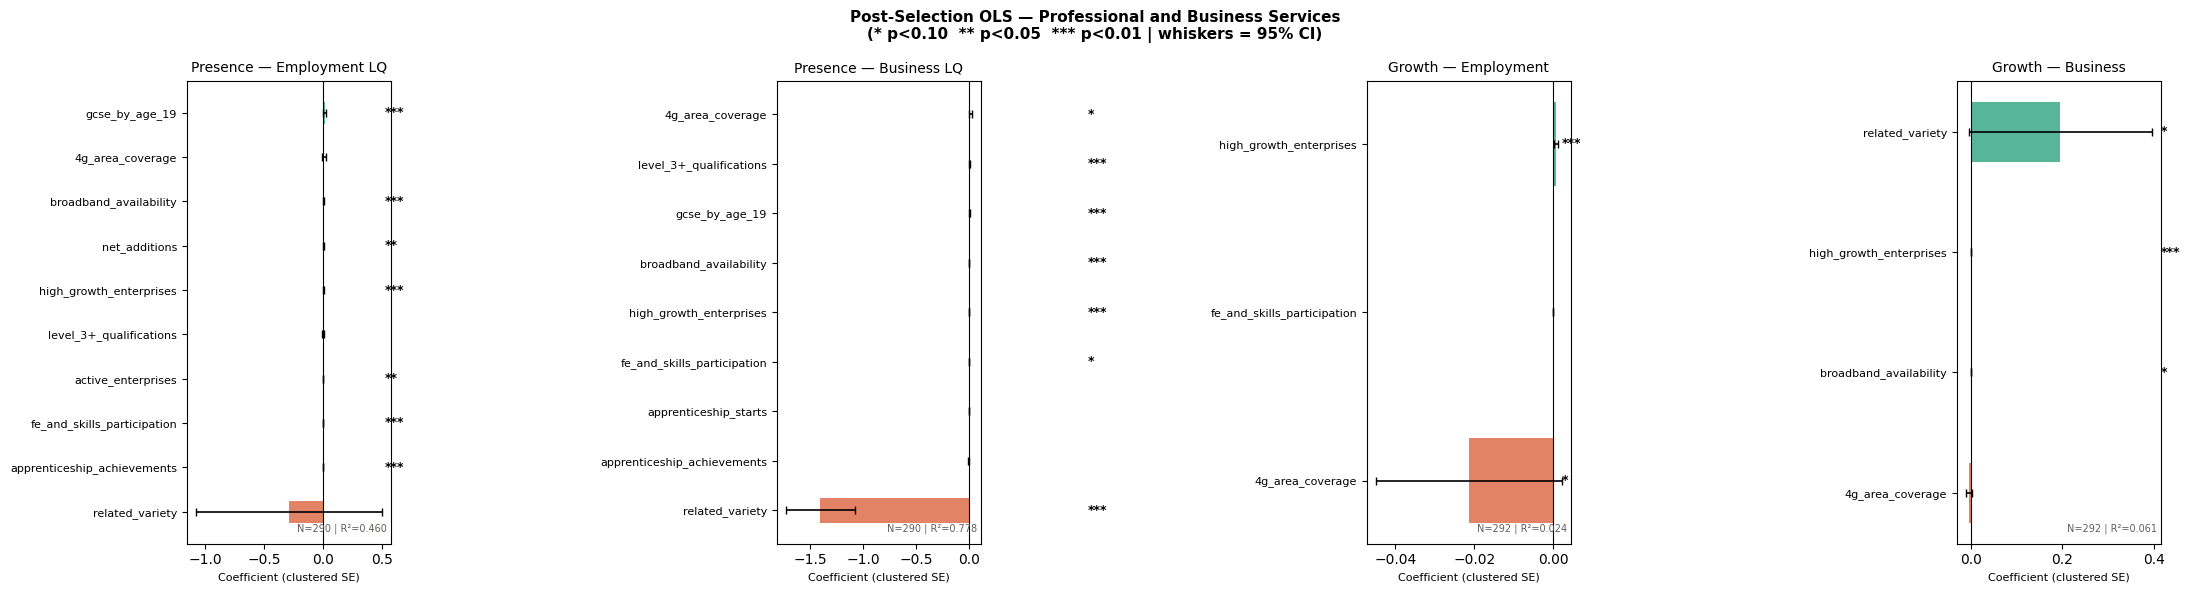


✅ Done. Outputs saved to: output\sector_models


In [35]:
OUTPUT_DIR = Path("output/sector_models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEAL  = "#1D9E75"
CORAL = "#D85A30"
GRAY  = "#5F5E5A"

OUTCOMES = {
    "lq_emp":     "Presence — Employment LQ",
    "lq_bus":     "Presence — Business LQ",
    "growth_emp": "Growth — Employment",
    "growth_bus": "Growth — Business",
}

SECTORS = [
    "Advanced Manufacturing",
    "Creative Industries",
    "Digital and Technologies",
    "Financial Services",
    "Life Sciences",
    "Professional and Business Services",
]

# ── SIGNIFICANCE STARS ────────────────────────────────────────
def stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

# ── POST-SELECTION OLS FUNCTION ───────────────────────────────
def run_ols(sector_df, y_col, selected_vars, sector_name, outcome_label):

    if not selected_vars:
        print(f"  ⚠ {sector_name} | {outcome_label}: no vars selected — skipped")
        return None

    cols    = ["geography_code"] + selected_vars + [y_col]
    data    = sector_df[cols].dropna()
    n       = len(data)

    if n < 30:
        print(f"  ⚠ {sector_name} | {outcome_label}: N={n} too small — skipped")
        return None

    # X and y as arrays (avoids patsy formula parser entirely)
    X = sm.add_constant(data[selected_vars].values.astype(float))
    y = data[y_col].values.astype(float)

    # Groups for clustering (LAD level)
    groups = data["geography_code"].values

    # Fit OLS with clustered standard errors
    model = sm.OLS(y, X).fit(
        cov_type="cluster",
        cov_kwds={"groups": groups}
    )

    # Build results table
    var_names = ["Intercept"] + selected_vars
    results = pd.DataFrame({
        "variable": var_names,
        "coef":     model.params,
        "se":       model.bse,
        "t":        model.tvalues,
        "p_value":  model.pvalues,
        "ci_low":   model.conf_int()[:, 0],
        "ci_high":  model.conf_int()[:, 1],
    })
    results["stars"] = results["p_value"].apply(stars)

    # Drop intercept row
    results = results[results["variable"] != "Intercept"].copy()

    print(f"  ✓ {sector_name} | {outcome_label}: "
          f"N={n} | R²={model.rsquared:.3f} | "
          f"Sig(5%): {(results['p_value'] < 0.05).sum()}/{len(selected_vars)}")

    return {
        "sector":        sector_name,
        "outcome":       y_col,
        "outcome_label": outcome_label,
        "n":             n,
        "r2":            round(model.rsquared,     3),
        "r2_adj":        round(model.rsquared_adj, 3),
        "results":       results,
    }

# ── RUN ALL MODELS ────────────────────────────────────────────
print("\n" + "="*60)
print("POST-SELECTION OLS")
print("="*60)

all_ols     = {}
ols_summary = []

for (sector, y_col), lasso_result in all_models.items():

    outcome_label = OUTCOMES[y_col]
    res           = lasso_result["results"]
    selected_vars = res[res["selected_both"]]["variable"].tolist()

    sector_df = df_cs[df_cs["is8_sector"] == sector].copy()

    print(f"\n── {sector} | {outcome_label} ──")
    ols = run_ols(sector_df, y_col, selected_vars,
                  sector, outcome_label)

    if ols is not None:
        all_ols[(sector, y_col)] = ols
        ols_summary.append({
            "sector":   sector,
            "outcome":  y_col,
            "n":        ols["n"],
            "r2":       ols["r2"],
            "r2_adj":   ols["r2_adj"],
            "n_vars":   len(selected_vars),
            "n_sig_05": int((ols["results"]["p_value"] < 0.05).sum()),
        })

# ── SUMMARY TABLE ─────────────────────────────────────────────
summary_df = pd.DataFrame(ols_summary)
print("\n" + "="*60)
print(summary_df.to_string(index=False))
summary_df.to_csv(OUTPUT_DIR / "ols_summary.csv", index=False)

# ── SAVE FULL COEFFICIENTS ────────────────────────────────────
all_rows = []
for (sector, y_col), ols in all_ols.items():
    res = ols["results"].copy()
    res["sector"]  = sector
    res["outcome"] = y_col
    res["n"]       = ols["n"]
    res["r2"]      = ols["r2"]
    all_rows.append(res)

if all_rows:
    pd.concat(all_rows, ignore_index=True).to_csv(
        OUTPUT_DIR / "ols_all_coefficients.csv", index=False
    )

# ── PLOT: COEFFICIENT PLOTS WITH CI AND STARS ─────────────────
for sector in SECTORS:
    fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=False)
    fig.suptitle(
        f"Post-Selection OLS — {sector}\n"
        f"(* p<0.10  ** p<0.05  *** p<0.01 | whiskers = 95% CI)",
        fontsize=11, fontweight="bold"
    )

    for ax_idx, (y_col, outcome_label) in enumerate(OUTCOMES.items()):
        ax = axes[ax_idx]

        if (sector, y_col) not in all_ols:
            ax.text(0.5, 0.5, "No variables\nselected",
                    ha="center", va="center",
                    transform=ax.transAxes, color=GRAY, fontsize=10)
            ax.set_title(outcome_label, fontsize=10)
            continue

        ols = all_ols[(sector, y_col)]
        res = ols["results"].sort_values("coef")
        y_pos  = np.arange(len(res))
        colors = [CORAL if c < 0 else TEAL for c in res["coef"]]

        # Bars
        ax.barh(y_pos, res["coef"].values,
                color=colors, alpha=0.75, height=0.5)

        # Confidence interval whiskers
        ax.errorbar(
            x=res["coef"].values, y=y_pos,
            xerr=[
                res["coef"].values - res["ci_low"].values,
                res["ci_high"].values - res["coef"].values
            ],
            fmt="none", color="black", linewidth=1.2, capsize=3
        )

        # Stars next to bars
        x_max = res["ci_high"].abs().max()
        for i, (_, row) in enumerate(res.iterrows()):
            if row["stars"]:
                ax.text(x_max * 1.05, i, row["stars"],
                        va="center", fontsize=9, fontweight="bold")

        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(res["variable"].values, fontsize=8)
        ax.set_title(outcome_label, fontsize=10)
        ax.set_xlabel("Coefficient (clustered SE)", fontsize=8)
        ax.text(0.98, 0.02,
                f"N={ols['n']} | R²={ols['r2']:.3f}",
                transform=ax.transAxes, fontsize=7,
                ha="right", va="bottom", color=GRAY)

    plt.tight_layout()
    slug = sector.lower().replace(" ", "_").replace("&", "and")
    plt.savefig(OUTPUT_DIR / f"ols_{slug}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

print("\n✅ Done. Outputs saved to:", OUTPUT_DIR)

In [36]:
# ── PRINT CLEAN OLS TABLES ────────────────────────────────────

for sector in SECTORS:
    print(f"\n{'='*70}")
    print(f"SECTOR: {sector}")
    print(f"{'='*70}")

    for y_col, outcome_label in OUTCOMES.items():
        if (sector, y_col) not in all_ols:
            continue

        ols = all_ols[(sector, y_col)]
        res = ols["results"].copy()

        # Format table
        res["coef_se"] = res.apply(
            lambda r: f"{r['coef']:.3f} ({r['se']:.3f}){r['stars']}", axis=1
        )
        res["ci"] = res.apply(
            lambda r: f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]", axis=1
        )

        table = res[["variable", "coef_se", "ci", "p_value"]].copy()
        table["p_value"] = table["p_value"].apply(lambda x: f"{x:.3f}")
        table.columns    = ["Variable", "Coef (SE)", "95% CI", "p-value"]

        print(f"\n{outcome_label} | N={ols['n']} | R²={ols['r2']} | Adj.R²={ols['r2_adj']}")
        print(table.to_string(index=False))
        print(f"\nNote: * p<0.10  ** p<0.05  *** p<0.01")

# ── EXPORT AS EXCEL WITH ONE SHEET PER SECTOR ─────────────────
with pd.ExcelWriter(OUTPUT_DIR / "ols_results.xlsx") as writer:
    for sector in SECTORS:
        sector_rows = []
        for y_col, outcome_label in OUTCOMES.items():
            if (sector, y_col) not in all_ols:
                continue
            ols = all_ols[(sector, y_col)]
            res = ols["results"].copy()
            res.insert(0, "outcome", outcome_label)
            res.insert(1, "N",  ols["n"])
            res.insert(2, "R2", ols["r2"])
            sector_rows.append(res)

        if sector_rows:
            slug = sector[:30]  # Excel sheet name max 31 chars
            pd.concat(sector_rows).to_excel(
                writer, sheet_name=slug, index=False
            )

print("✅ Excel table saved to output/sector_models/ols_results.xlsx")


SECTOR: Advanced Manufacturing

Presence — Employment LQ | N=291 | R²=0.199 | Adj.R²=0.182
                   Variable       Coef (SE)          95% CI p-value
      apprenticeship_starts   0.001 (0.001) [-0.000, 0.002]   0.146
apprenticeship_achievements   0.001 (0.001) [-0.002, 0.004]   0.620
      deaths_of_enterprises   0.000 (0.000) [-0.000, 0.000]   0.791
         active_enterprises  -0.000 (0.000) [-0.000, 0.000]   0.181
           4g_area_coverage  -0.193 (0.170) [-0.527, 0.140]   0.256
              net_additions 0.052 (0.022)**  [0.009, 0.094]   0.017

Note: * p<0.10  ** p<0.05  *** p<0.01

Presence — Business LQ | N=290 | R²=0.401 | Adj.R²=0.378
                   Variable         Coef (SE)           95% CI p-value
    level_3+_qualifications -0.008 (0.003)*** [-0.014, -0.002]   0.010
             gcse_by_age_19 -0.010 (0.004)*** [-0.017, -0.003]   0.008
      apprenticeship_starts  0.001 (0.000)***   [0.000, 0.001]   0.000
fe_and_skills_participation    -0.000 (0.000)  [-0.

In [37]:
# Check if region variable exists
print(df.columns.tolist())

# Check if geography_name gives us a clue
print(df['geography_name'].unique()[:20])

['year', 'geography_code', 'geography_name', 'is8_sector', 'employees', 'businesses', 'gva_per_hour', 'weekly_pay', 'employment_rate', 'unemployment_rate', 'gdhi_per_head', 'new_enterprises', 'deaths_of_enterprises', 'active_enterprises', 'high_growth_enterprises', 'public_transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband_availability', '4g_area_coverage', 'ks2_attainment', 'gcse_by_age_19', 'ofsted', 'persistent_absences', 'persistent_absences_fsm', 'persistent_absences_cla', 'early_years_comms', 'early_years_literacy', 'early_years_maths', 'fe_and_skills_achievements', 'apprenticeship_starts', 'apprenticeship_achievements', 'level_3+_qualifications', 'fe_and_skills_participation', 'female_hle', 'male_hle', 'smokers', 'reception_obesity', 'year_6_obesity', 'adult_obesity', 'cancer_diagnosis', 'under_75_mortality_rate', 'life_satisfaction', 'worthwhile', 'happiness', 'anxiety', 'net_additions', 'lq_bus', 'emp_share', 'lq_emp', 'growth_emp', 'cagr_emp', 'growt

Lookup loaded: 296 LADs
['North East' 'North West' 'Yorkshire and The Humber' 'East Midlands'
 'West Midlands' 'South West' 'East of England' 'South East' 'London']

Matched: 2072 rows
Unmatched (Scotland/Wales): 378 rows


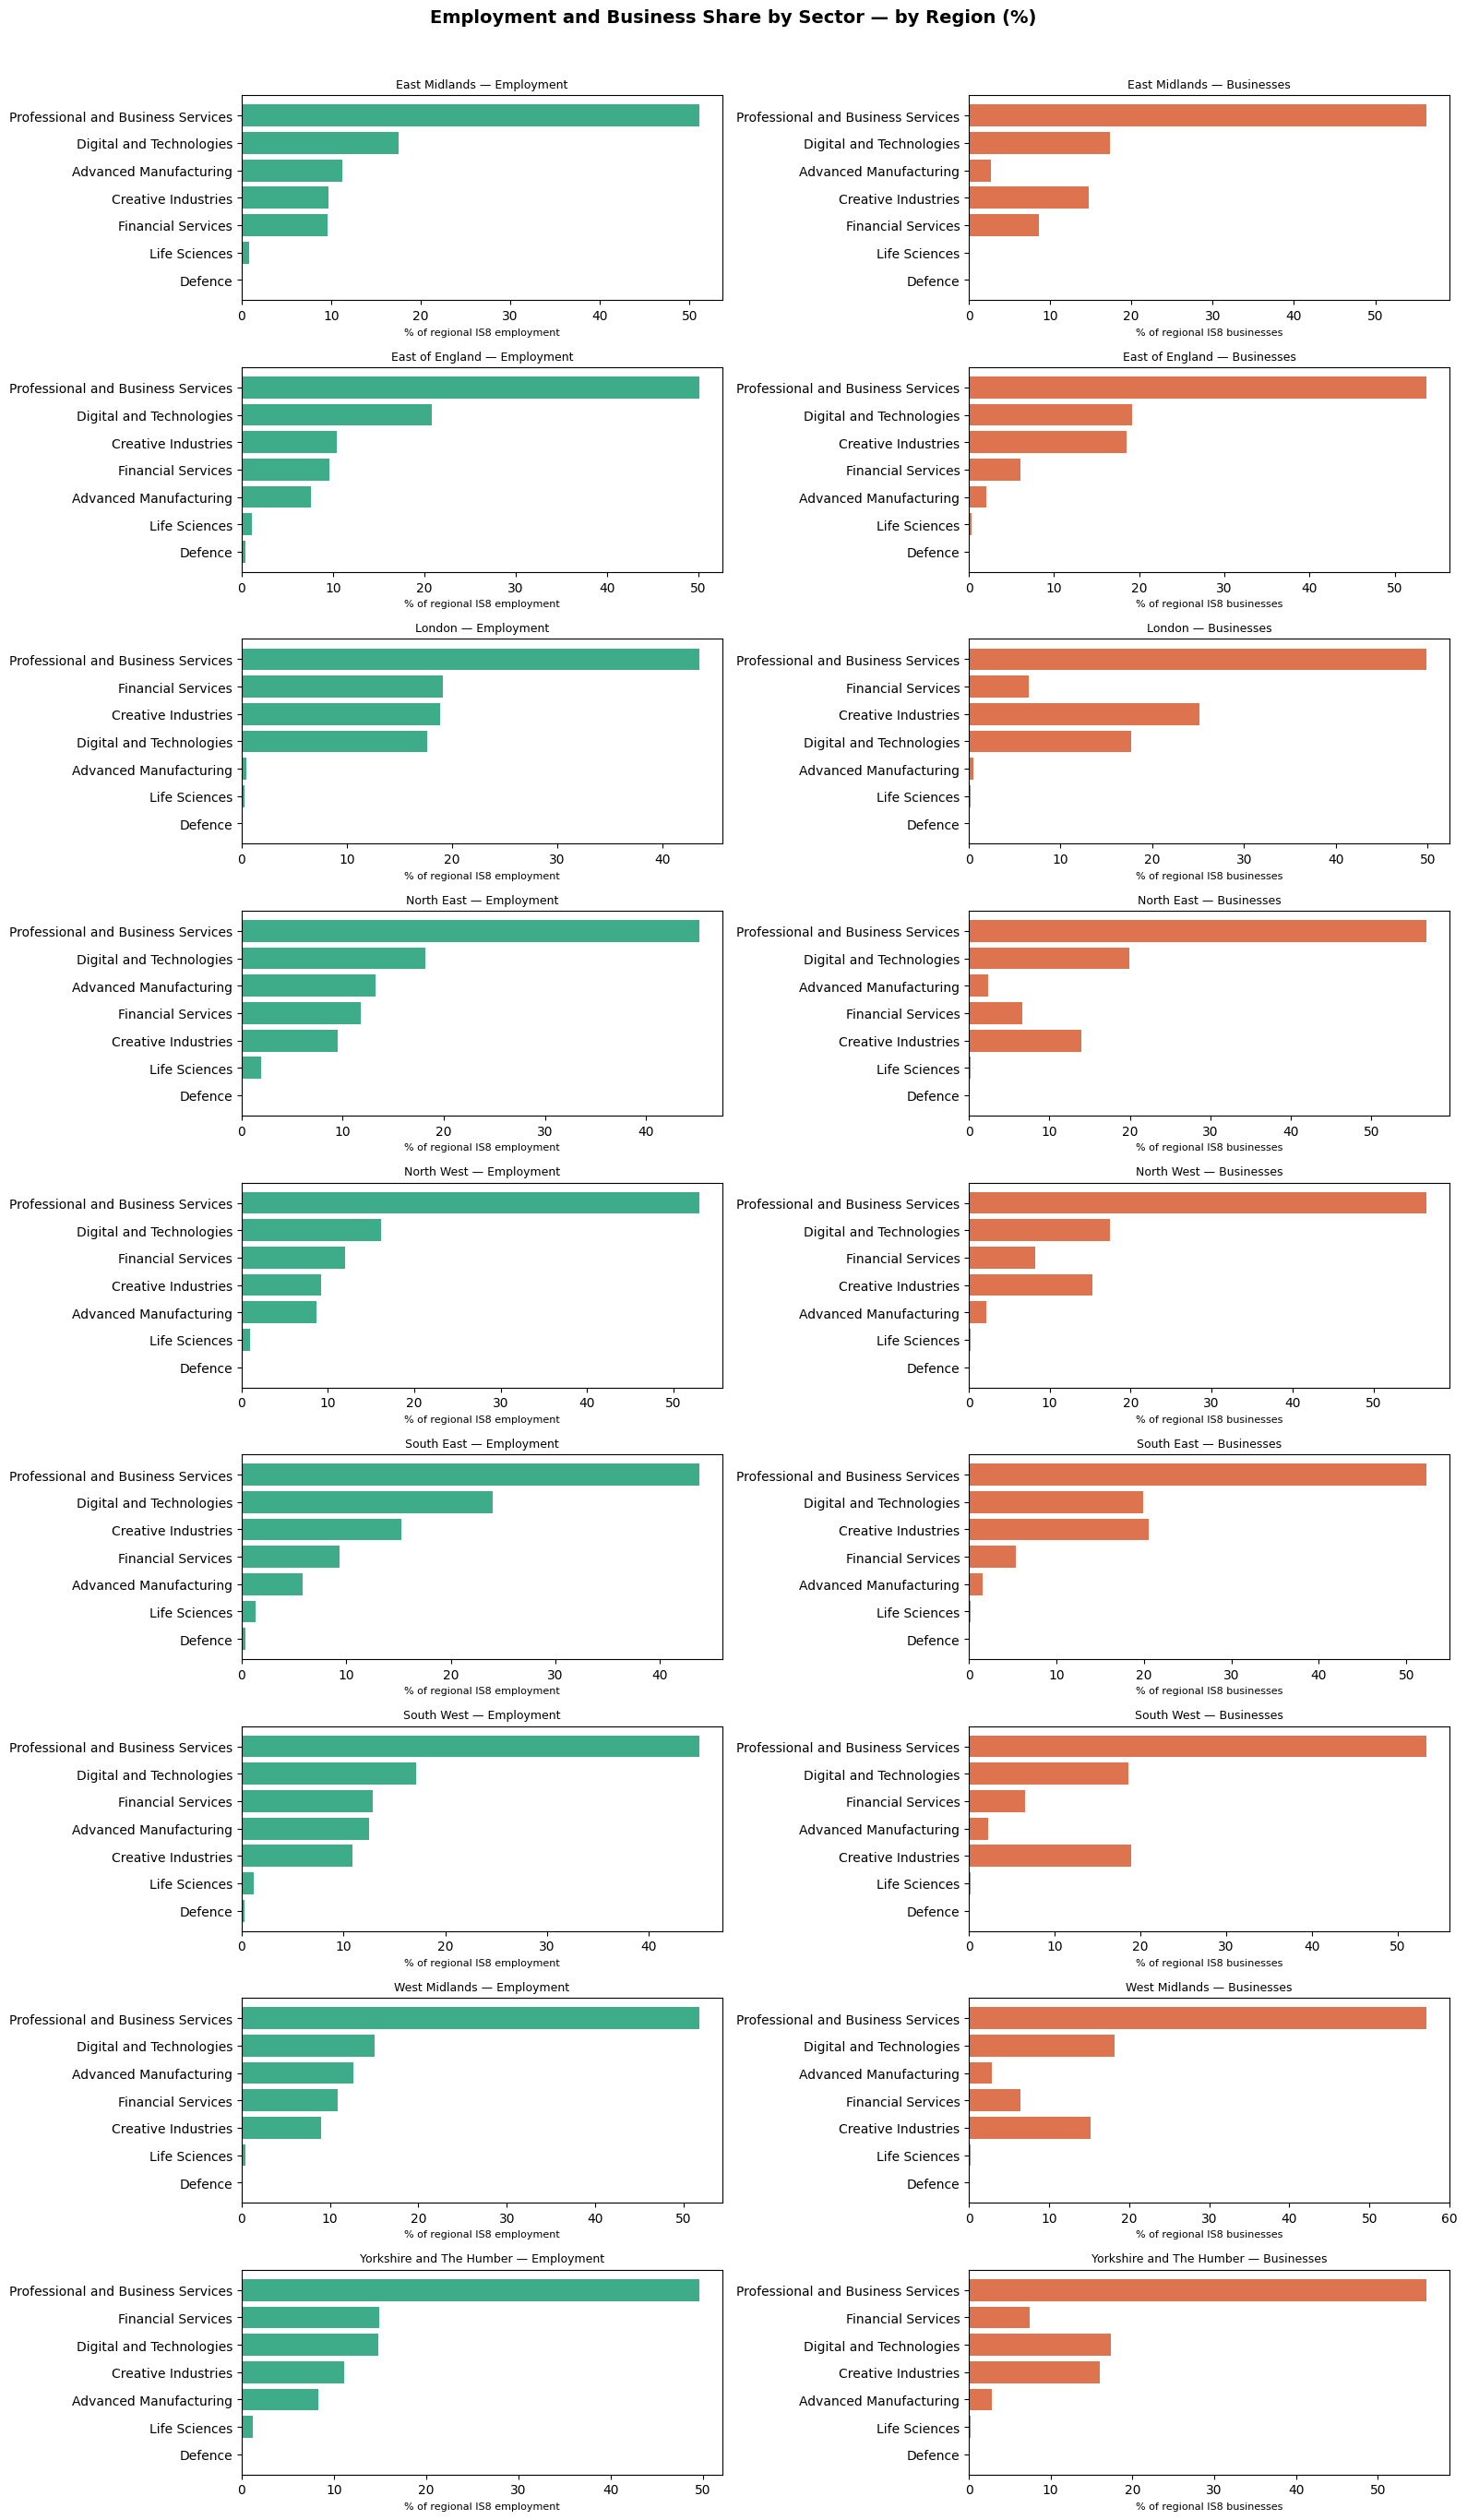

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── STEP 1: LOAD LAD TO REGION LOOKUP ────────────────────────
# ONS official lookup — England only (E codes)
lookup_url = (
    "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/"
    "LAD23_RGN23_EN_LU/FeatureServer/0/query"
    "?where=1%3D1&outFields=LAD23CD,LAD23NM,RGN23CD,RGN23NM"
    "&resultRecordCount=500&f=json"
)

# Parse the ArcGIS JSON response
import requests
resp    = requests.get(lookup_url).json()
lookup  = pd.DataFrame([f["attributes"] for f in resp["features"]])
lookup  = lookup.rename(columns={
    "LAD23CD": "geography_code",
    "LAD23NM": "lad_name",
    "RGN23CD": "region_code",
    "RGN23NM": "region",
})
print(f"Lookup loaded: {lookup.shape[0]} LADs")
print(lookup["region"].unique())

# ── STEP 2: MERGE REGION INTO YOUR DATA ──────────────────────
END_YEAR = df["year"].max()
df_end   = df[df["year"] == END_YEAR].copy()

df_region = df_end.merge(
    lookup[["geography_code", "region"]],
    on="geography_code",
    how="left"
)

# Check how many LADs matched
print(f"\nMatched: {df_region['region'].notna().sum()} rows")
print(f"Unmatched (Scotland/Wales): {df_region['region'].isna().sum()} rows")

# Keep England only
df_region = df_region[df_region["region"].notna()].copy()

# ── STEP 3: CALCULATE SHARES BY REGION AND SECTOR ────────────
regional = (
    df_region.groupby(["region", "is8_sector"], observed=True)
    .agg(
        total_employees  = ("employees",  "sum"),
        total_businesses = ("businesses", "sum"),
    )
    .reset_index()
)

# Calculate share within each region (not national share)
regional["emp_share"] = (
    regional.groupby("region")["total_employees"]
    .transform(lambda x: x / x.sum() * 100)
)
regional["bus_share"] = (
    regional.groupby("region")["total_businesses"]
    .transform(lambda x: x / x.sum() * 100)
)

# ── STEP 4: PLOT ──────────────────────────────────────────────
TEAL  = "#1D9E75"
CORAL = "#D85A30"

regions = sorted(regional["region"].unique())
n_rows  = len(regions)

fig, axes = plt.subplots(n_rows, 2, figsize=(16, n_rows * 3))
fig.suptitle(
    "Employment and Business Share by Sector — by Region (%)",
    fontsize=14, fontweight="bold", y=1.01
)

for i, region in enumerate(regions):
    data = regional[regional["region"] == region].sort_values(
        "emp_share", ascending=True
    )

    # Employment share
    axes[i, 0].barh(data["is8_sector"], data["emp_share"],
                    color=TEAL, alpha=0.85)
    axes[i, 0].set_title(f"{region} — Employment", fontsize=9)
    axes[i, 0].set_xlabel("% of regional IS8 employment", fontsize=8)

    # Business share
    axes[i, 1].barh(data["is8_sector"], data["bus_share"],
                    color=CORAL, alpha=0.85)
    axes[i, 1].set_title(f"{region} — Businesses", fontsize=9)
    axes[i, 1].set_xlabel("% of regional IS8 businesses", fontsize=8)

plt.tight_layout()
plt.savefig("output/sector_models/shares_by_region.png",
            dpi=150, bbox_inches="tight")
plt.show()